# BVH Benchmark — Paper Plots
Configure the `DATA_DIR` and file naming convention below, then run all cells.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import re, warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 12,
    'legend.fontsize': 10, 'figure.dpi': 150,
    'savefig.bbox': 'tight', 'savefig.dpi': 300,
})

# ============================================================
# CONFIGURE HERE
# ============================================================
DATA_DIR = Path('.')  # folder containing all CSVs

METHODS = ['AwareBVH', 'KineticBVH', 'RefitRotate', 'DynamicBVH']
METHOD_LABELS = {
    'AwareBVH': 'Deformation-Aware',
    'KineticBVH': 'Kinetic BVH',
    'RefitRotate': 'Refit+Rotation',
    'DynamicBVH': 'Dynamic Fat-Bounds',
}
METHOD_COLORS = {
    'AwareBVH': '#1f77b4',
    'KineticBVH': '#d62728',
    'RefitRotate': '#2ca02c',
    'DynamicBVH': '#ff7f0e',
}
METHOD_MARKERS = {
    'AwareBVH': 'o',
    'KineticBVH': 's',
    'RefitRotate': '^',
    'DynamicBVH': 'D',
}

MESHES = ['Suzanne', 'Dragon', 'Plane']

# Map mesh name -> list of (label, triangle_count) in ascending order
MESH_RESOLUTIONS = {
    'Suzanne': [('4K', 3936), ('16K', 15744), ('63K', 62976), ('252K', 251904)],
    'Dragon':  [('3K', 3402), ('14K', 13614), ('54K', 54456), ('218K', 217826)],
    'Plane':   [('4K', 4352), ('17K', 16896), ('67K', 66560), ('264K', 264192)],
}

DEFORMATIONS = ['SineWave', 'Twist', 'Localized']

SAVE_PLOTS = False  # set True to save PDFs

In [2]:
def load_csv(path):
    """Load a benchmark CSV, skipping comment header."""
    df = pd.read_csv(path, comment='#')
    # Parse metadata from comment line
    meta = {}
    with open(path) as f:
        for line in f:
            if line.startswith('#'):
                for pair in line[2:].split(','):
                    if '=' in pair:
                        k, v = pair.strip().split('=', 1)
                        meta[k.strip()] = v.strip()
                break
    return df, meta

def find_file(method, deformation, mesh=None, tri_count=None):
    """Find CSV matching the given parameters. Adjust pattern to your naming."""
    pattern = f'*{method}*{deformation}*.csv'
    candidates = sorted(DATA_DIR.glob(pattern))
    if tri_count and candidates:
        # Filter by triangle count in metadata
        filtered = []
        for c in candidates:
            _, meta = load_csv(c)
            if 'triangles' in meta and int(meta['triangles']) == tri_count:
                filtered.append(c)
        if filtered:
            return filtered[-1]  # latest timestamp
    return candidates[-1] if candidates else None

def load_method_data(method, deformation, tri_count=None):
    """Load data for a specific method+deformation+resolution."""
    f = find_file(method, deformation, tri_count=tri_count)
    if f is None:
        return None, None
    return load_csv(f)

def get_averaged_line(df, col, n_points=300):
    """Average a metric across runs, interpolated to common x-axis."""
    common_x = np.linspace(0, 100, n_points)
    all_y = []
    for run_id in df['run'].unique():
        rd = df[df['run'] == run_id].sort_values('cycleProgress')
        if len(rd) < 2: continue
        y_interp = np.interp(common_x, rd['cycleProgress'] * 100, rd[col])
        all_y.append(y_interp)
    if not all_y:
        return common_x, np.zeros(n_points), np.zeros(n_points)
    return common_x, np.mean(all_y, axis=0), np.std(all_y, axis=0)

def savefig(name):
    if SAVE_PLOTS:
        plt.savefig(f'{name}.pdf', bbox_inches='tight')

print(f'Data directory: {DATA_DIR.resolve()}')
print(f'CSV files found: {len(list(DATA_DIR.glob("*.csv")))}')

Data directory: D:\o1a2h\Programming\Unity\AwareBVH\Assets\Benchmark
CSV files found: 4


---
## Figure 1 — Scaling: Update Time vs Triangle Count
One subplot per mesh type. Shows how each method scales with resolution.  
**This is the hero scaling figure for the paper.**

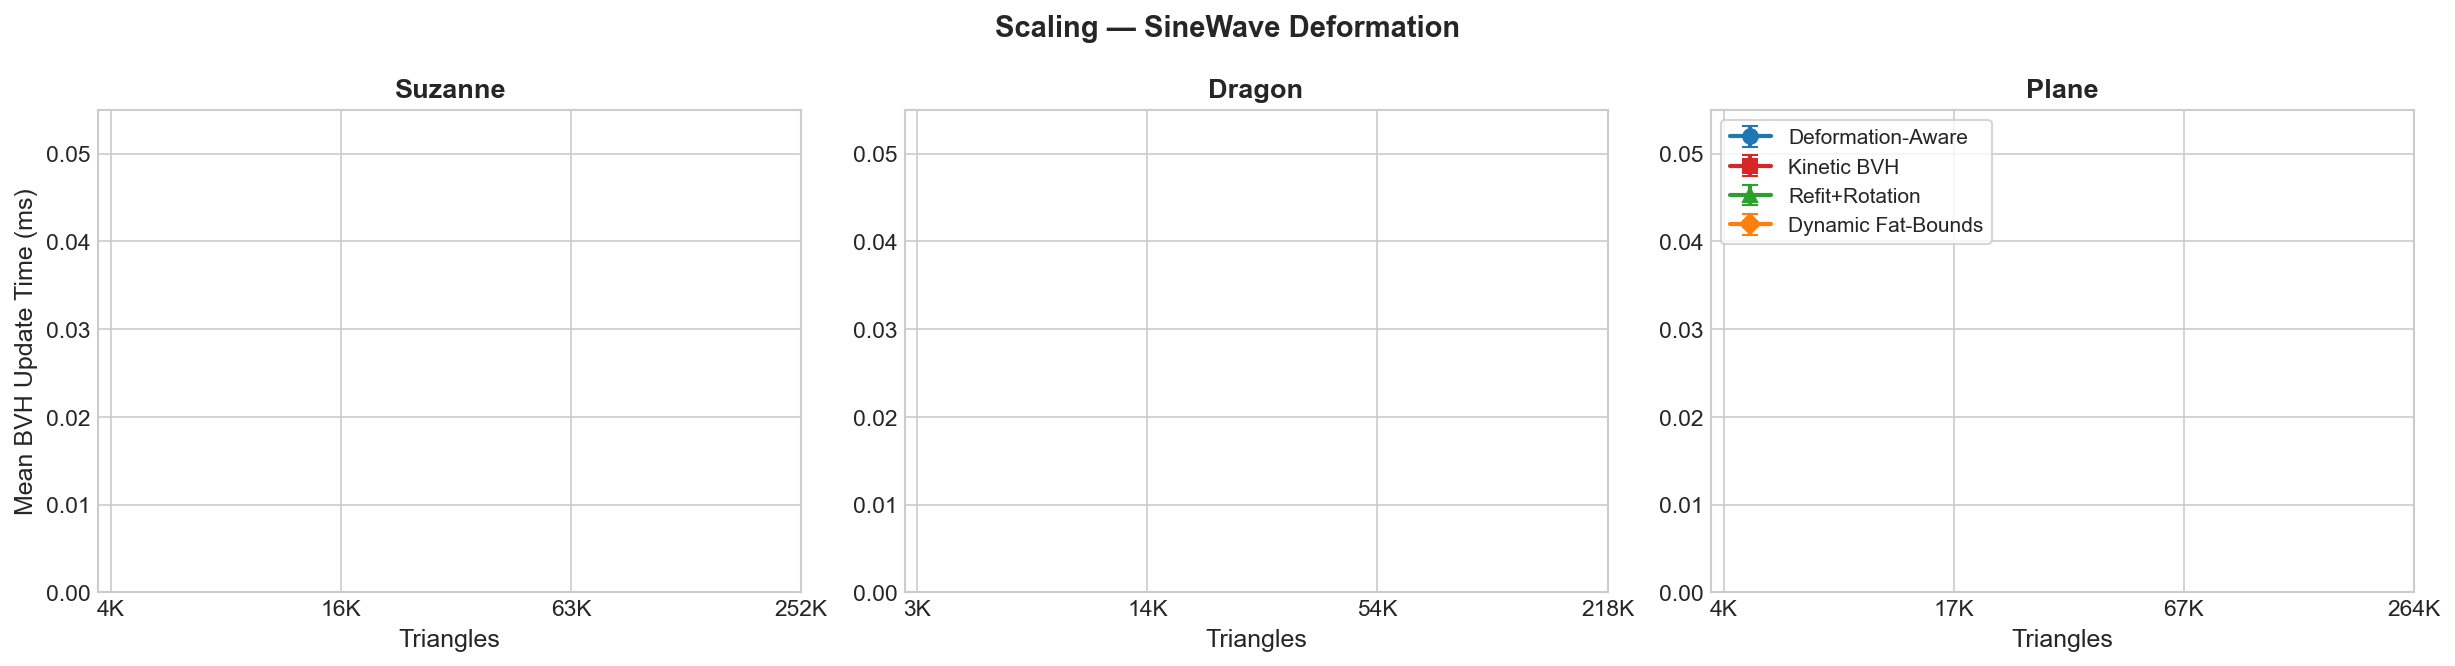

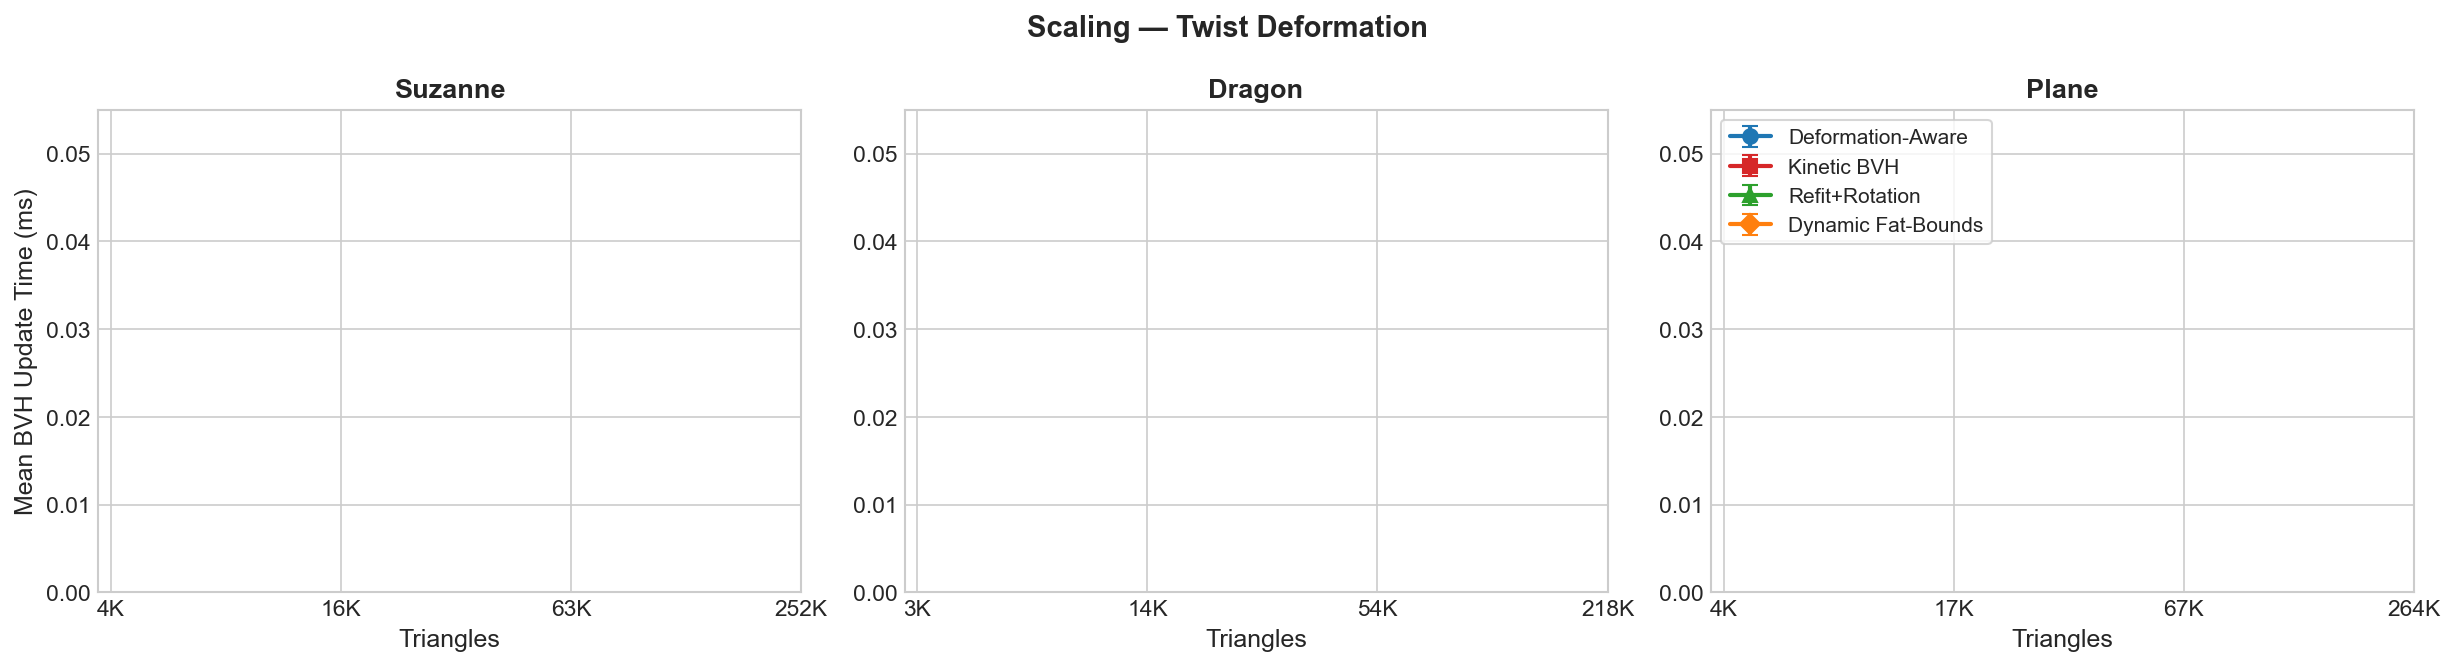

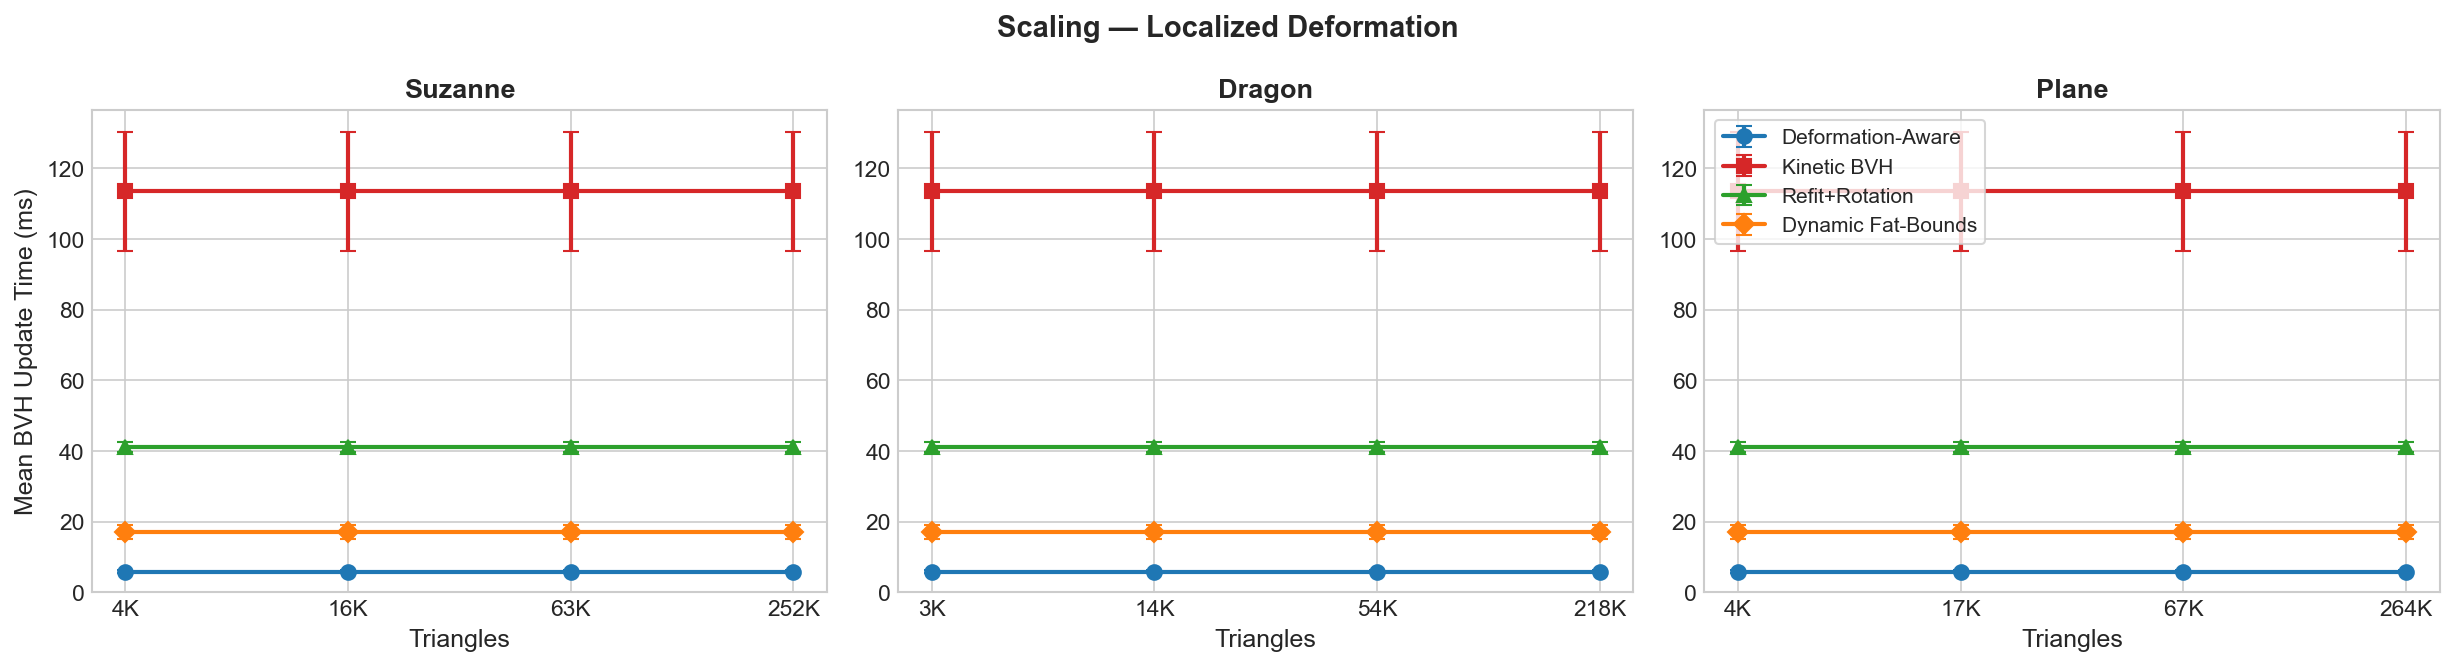

In [3]:
def plot_scaling(deformation, metric='updateMs', ylabel='Mean BVH Update Time (ms)'):
    fig, axes = plt.subplots(1, len(MESHES), figsize=(5.5 * len(MESHES), 4.5), sharey=False)
    if len(MESHES) == 1: axes = [axes]

    for ax, mesh in zip(axes, MESHES):
        resolutions = MESH_RESOLUTIONS[mesh]
        tri_counts = [r[1] for r in resolutions]
        labels_x = [r[0] for r in resolutions]

        for method in METHODS:
            means, stds = [], []
            for _, tri_count in resolutions:
                df, _ = load_method_data(method, deformation, tri_count)
                if df is not None and len(df) > 0:
                    means.append(df[metric].mean())
                    stds.append(df[metric].std())
                else:
                    means.append(np.nan)
                    stds.append(0)

            ax.errorbar(range(len(tri_counts)), means, yerr=stds,
                       marker=METHOD_MARKERS[method], color=METHOD_COLORS[method],
                       linewidth=2, markersize=7, capsize=4,
                       label=METHOD_LABELS[method])

        ax.set_title(f'{mesh}', fontweight='bold')
        ax.set_xticks(range(len(labels_x)))
        ax.set_xticklabels(labels_x)
        ax.set_xlabel('Triangles')
        ax.set_ylim(bottom=0)

    axes[0].set_ylabel(ylabel)
    axes[-1].legend(loc='upper left', frameon=True)
    fig.suptitle(f'Scaling — {deformation} Deformation', fontweight='bold', fontsize=14)
    plt.tight_layout()
    savefig(f'fig_scaling_{deformation.lower()}')
    plt.show()

for d in DEFORMATIONS:
    plot_scaling(d)

---
## Figure 2 — BVH Overhead Comparison (Grouped Bars)
For each mesh at highest resolution: bars showing BVH overhead per method.  
Side-by-side bars for each deformation type.

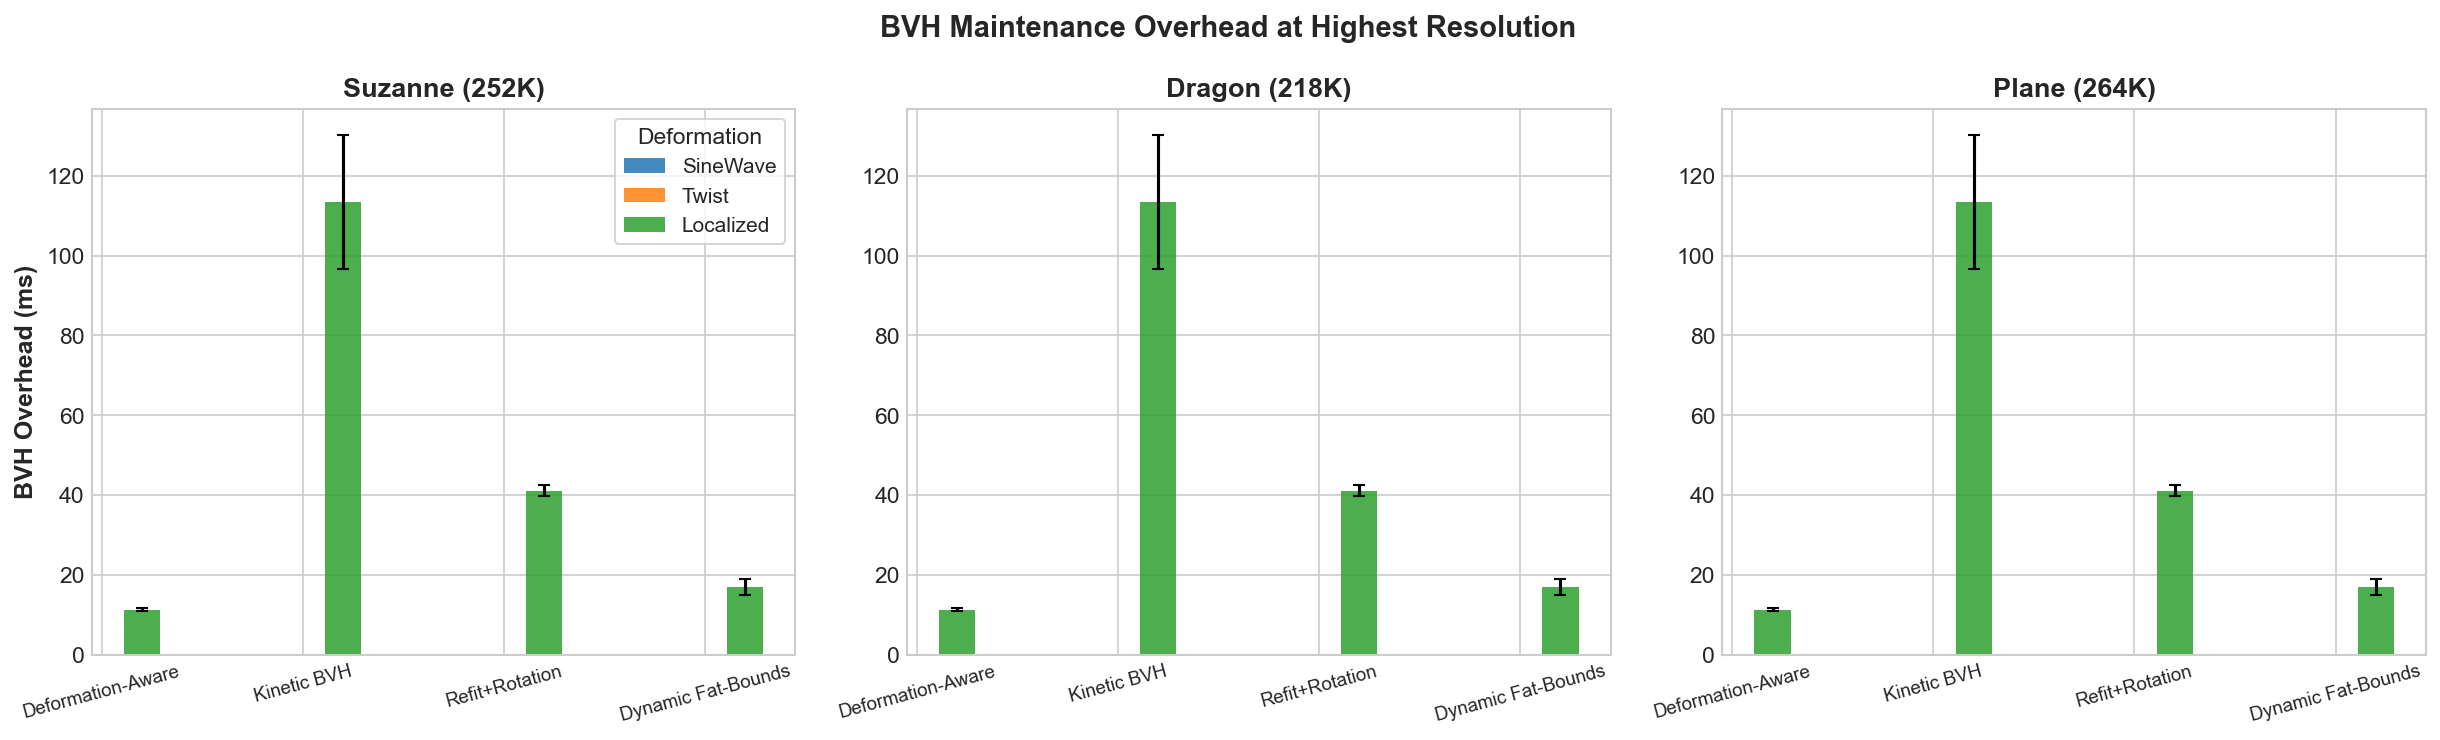

In [4]:
def compute_overhead(method, deformation, tri_count):
    """BVH overhead = updateMs for non-Aware; (deformMs - baseline_deform) + updateMs for Aware."""
    df, _ = load_method_data(method, deformation, tri_count)
    if df is None: return np.nan, np.nan

    if method == 'AwareBVH':
        # Need baseline deform from another method
        df_ref, _ = load_method_data('RefitRotate', deformation, tri_count)
        if df_ref is None:
            baseline = df['deformMs'].mean() * 0.7  # rough estimate
        else:
            baseline = df_ref['deformMs'].mean()
        overhead = (df['deformMs'].mean() - baseline) + df['updateMs'].mean()
        std = df['updateMs'].std()
    else:
        overhead = df['updateMs'].mean()
        std = df['updateMs'].std()
    return overhead, std

fig, axes = plt.subplots(1, len(MESHES), figsize=(5.5 * len(MESHES), 5), sharey=False)
if len(MESHES) == 1: axes = [axes]

bar_width = 0.2
x = np.arange(len(METHODS))

for ax, mesh in zip(axes, MESHES):
    _, max_tris = MESH_RESOLUTIONS[mesh][-1]  # highest resolution

    for di, deform in enumerate(DEFORMATIONS):
        means, stds = [], []
        for method in METHODS:
            m, s = compute_overhead(method, deform, max_tris)
            means.append(m)
            stds.append(s)

        offset = (di - len(DEFORMATIONS)/2 + 0.5) * bar_width
        bars = ax.bar(x + offset, means, bar_width * 0.9, yerr=stds,
                     capsize=3, label=deform if mesh == MESHES[0] else None,
                     alpha=0.85)

    ax.set_title(f'{mesh} ({MESH_RESOLUTIONS[mesh][-1][0]})', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([METHOD_LABELS[m] for m in METHODS], fontsize=9, rotation=15)
    ax.set_ylim(bottom=0)

axes[0].set_ylabel('BVH Overhead (ms)', fontweight='bold')
axes[0].legend(title='Deformation', frameon=True)
fig.suptitle('BVH Maintenance Overhead at Highest Resolution', fontweight='bold', fontsize=14)
plt.tight_layout()
savefig('fig_overhead_bars')
plt.show()

---
## Figure 3 — Vertex Work (Log-Scale Bars)
Shows vertices checked per frame — the algorithmic work difference.

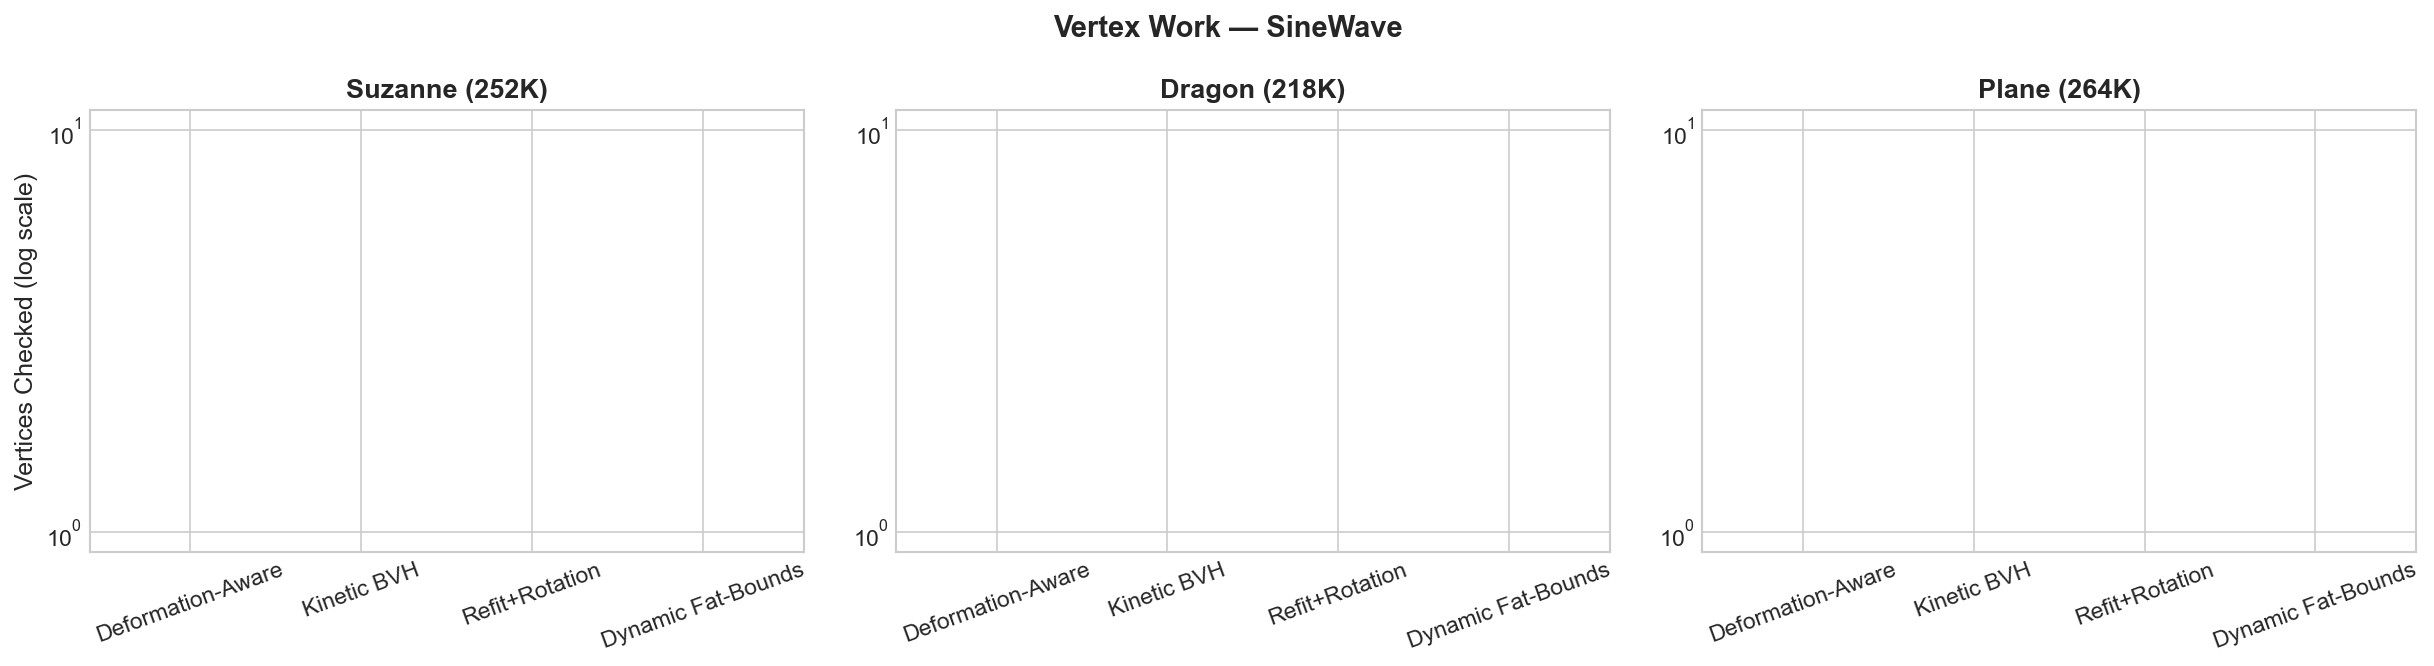

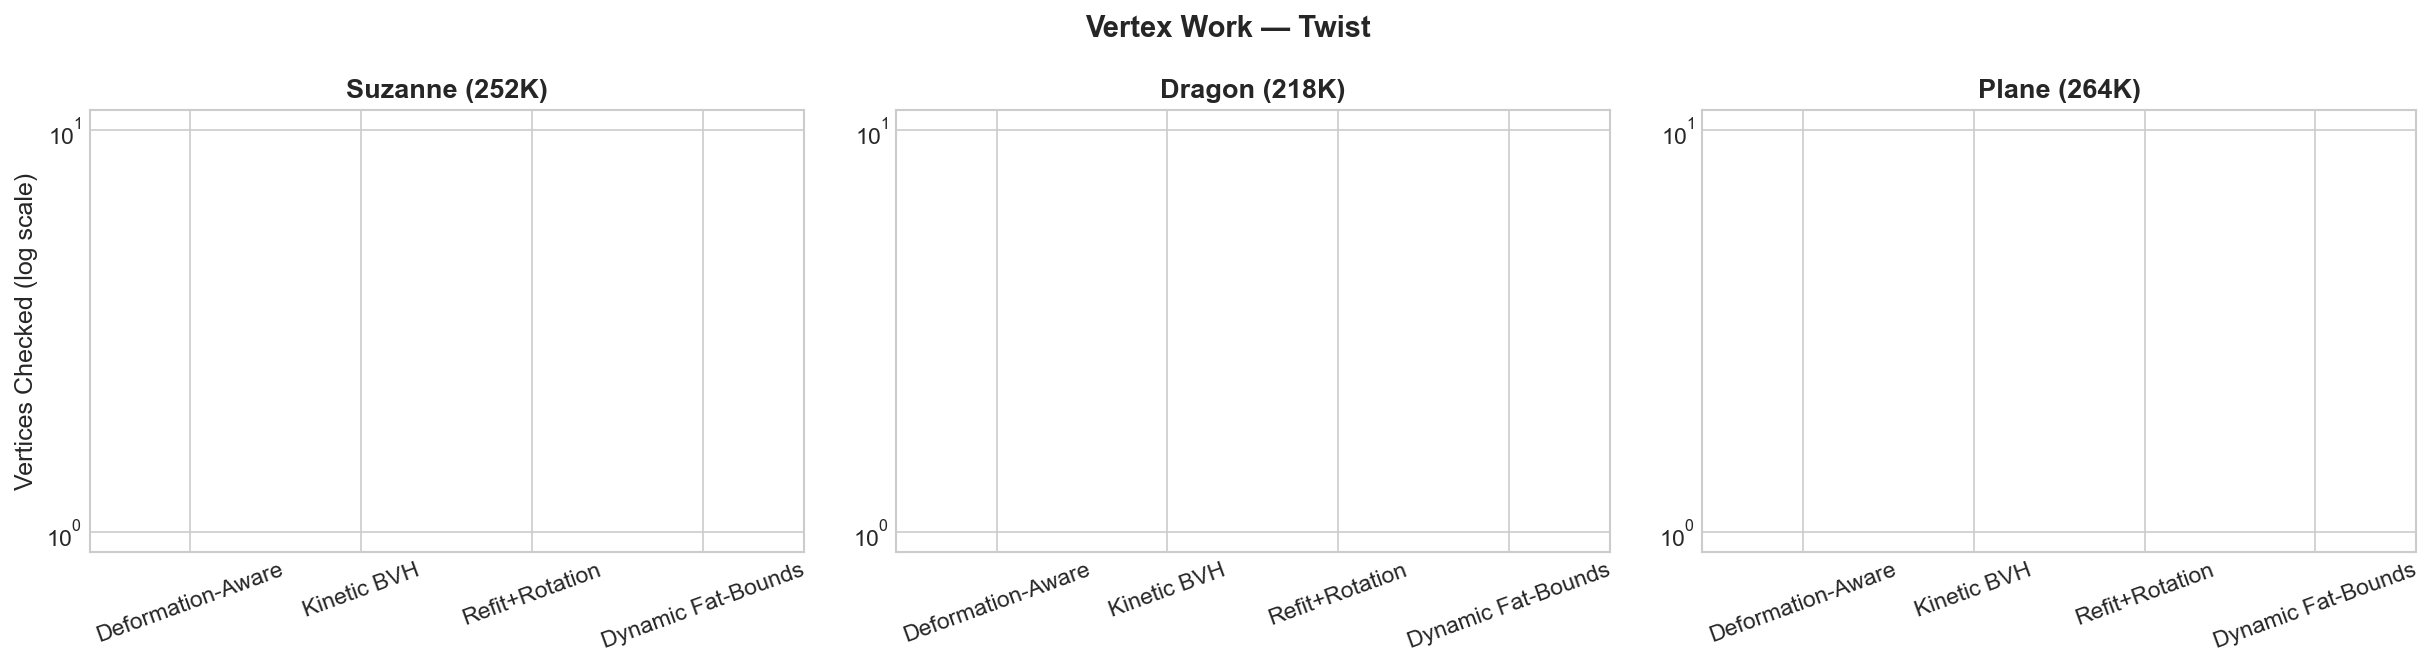

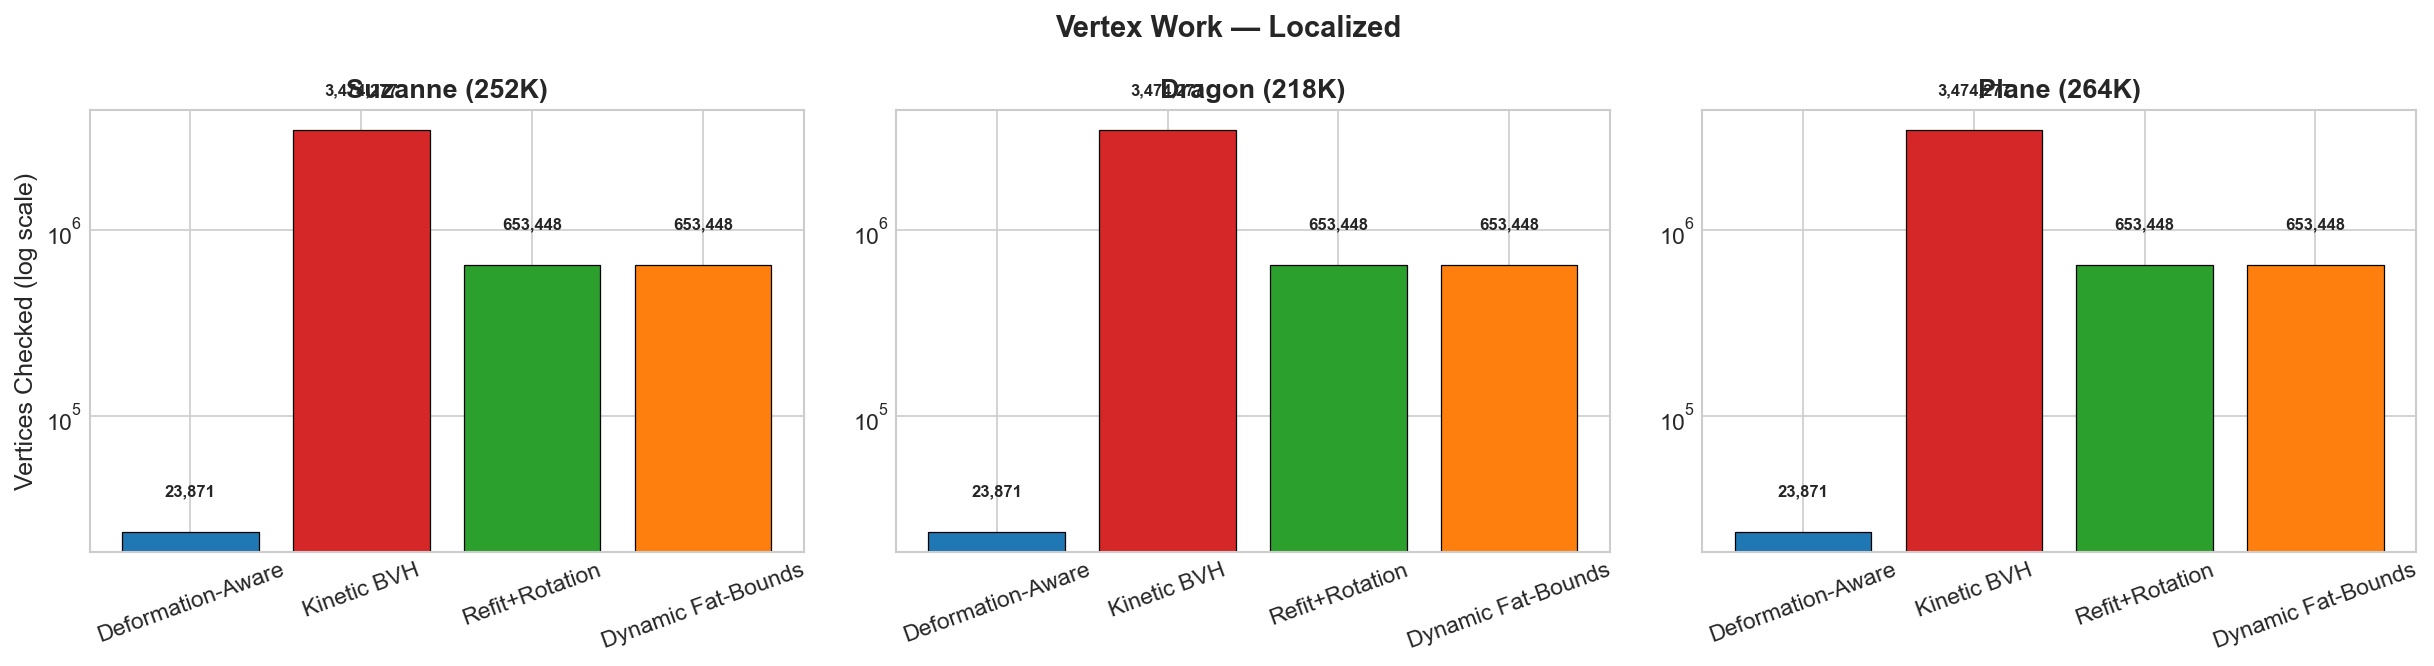

In [5]:
def plot_vertex_work(deformation):
    fig, axes = plt.subplots(1, len(MESHES), figsize=(5.5 * len(MESHES), 4.5), sharey=False)
    if len(MESHES) == 1: axes = [axes]

    for ax, mesh in zip(axes, MESHES):
        _, max_tris = MESH_RESOLUTIONS[mesh][-1]
        means = []
        for method in METHODS:
            df, _ = load_method_data(method, deformation, max_tris)
            means.append(df['verticesChecked'].mean() if df is not None else 0)

        bars = ax.bar([METHOD_LABELS[m] for m in METHODS], means,
                     color=[METHOD_COLORS[m] for m in METHODS],
                     edgecolor='black', linewidth=0.6)
        ax.set_yscale('log')
        ax.set_title(f'{mesh} ({MESH_RESOLUTIONS[mesh][-1][0]})', fontweight='bold')
        ax.tick_params(axis='x', rotation=20)

        for bar, val in zip(bars, means):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.5,
                        f'{val:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    axes[0].set_ylabel('Vertices Checked (log scale)')
    fig.suptitle(f'Vertex Work — {deformation}', fontweight='bold', fontsize=14)
    plt.tight_layout()
    savefig(f'fig_vertex_work_{deformation.lower()}')
    plt.show()

for d in DEFORMATIONS:
    plot_vertex_work(d)

---
## Figure 4 — Dirty Node Percentage (Grouped Bars)
What fraction of the tree each method recomputes.

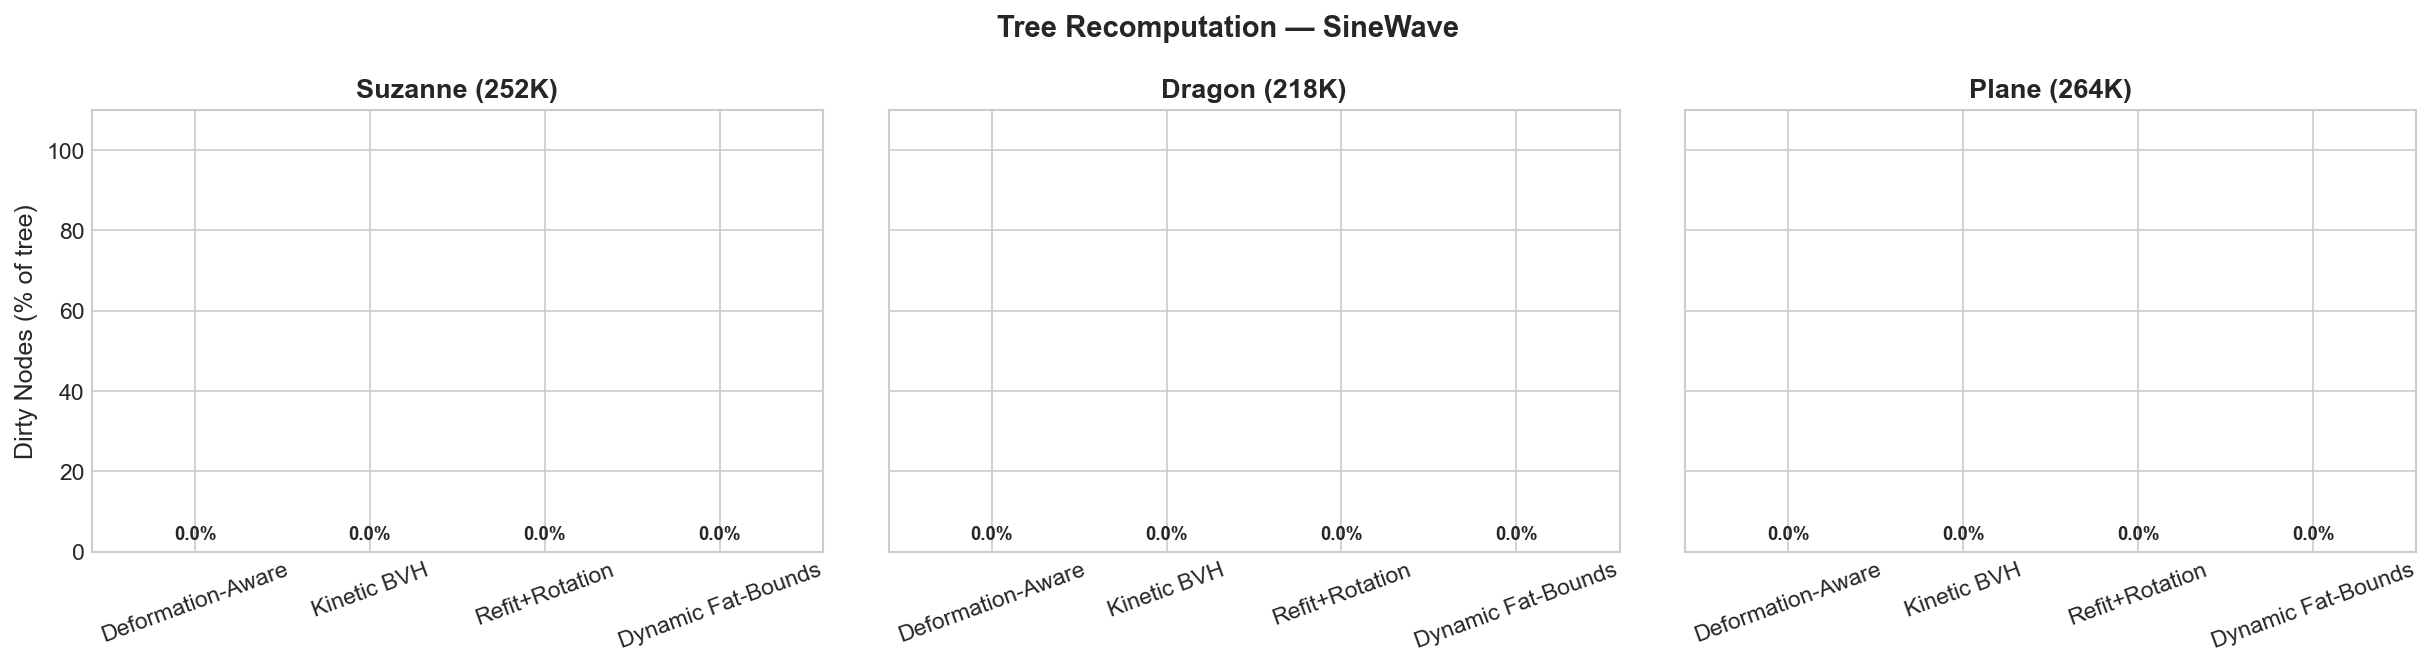

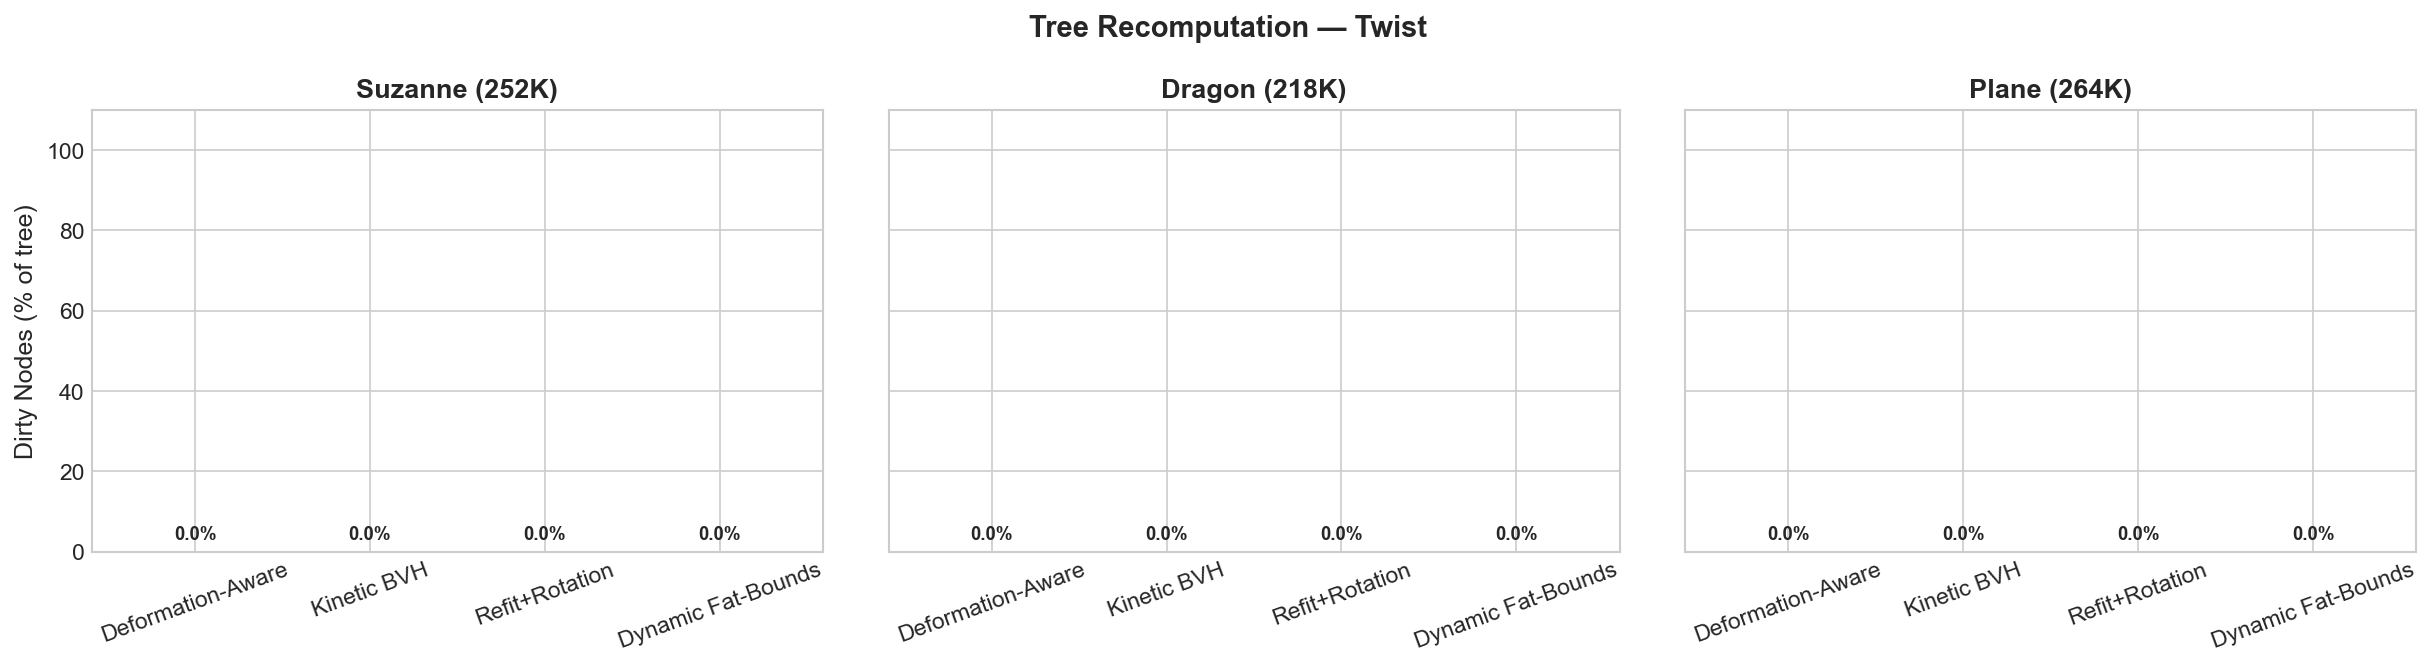

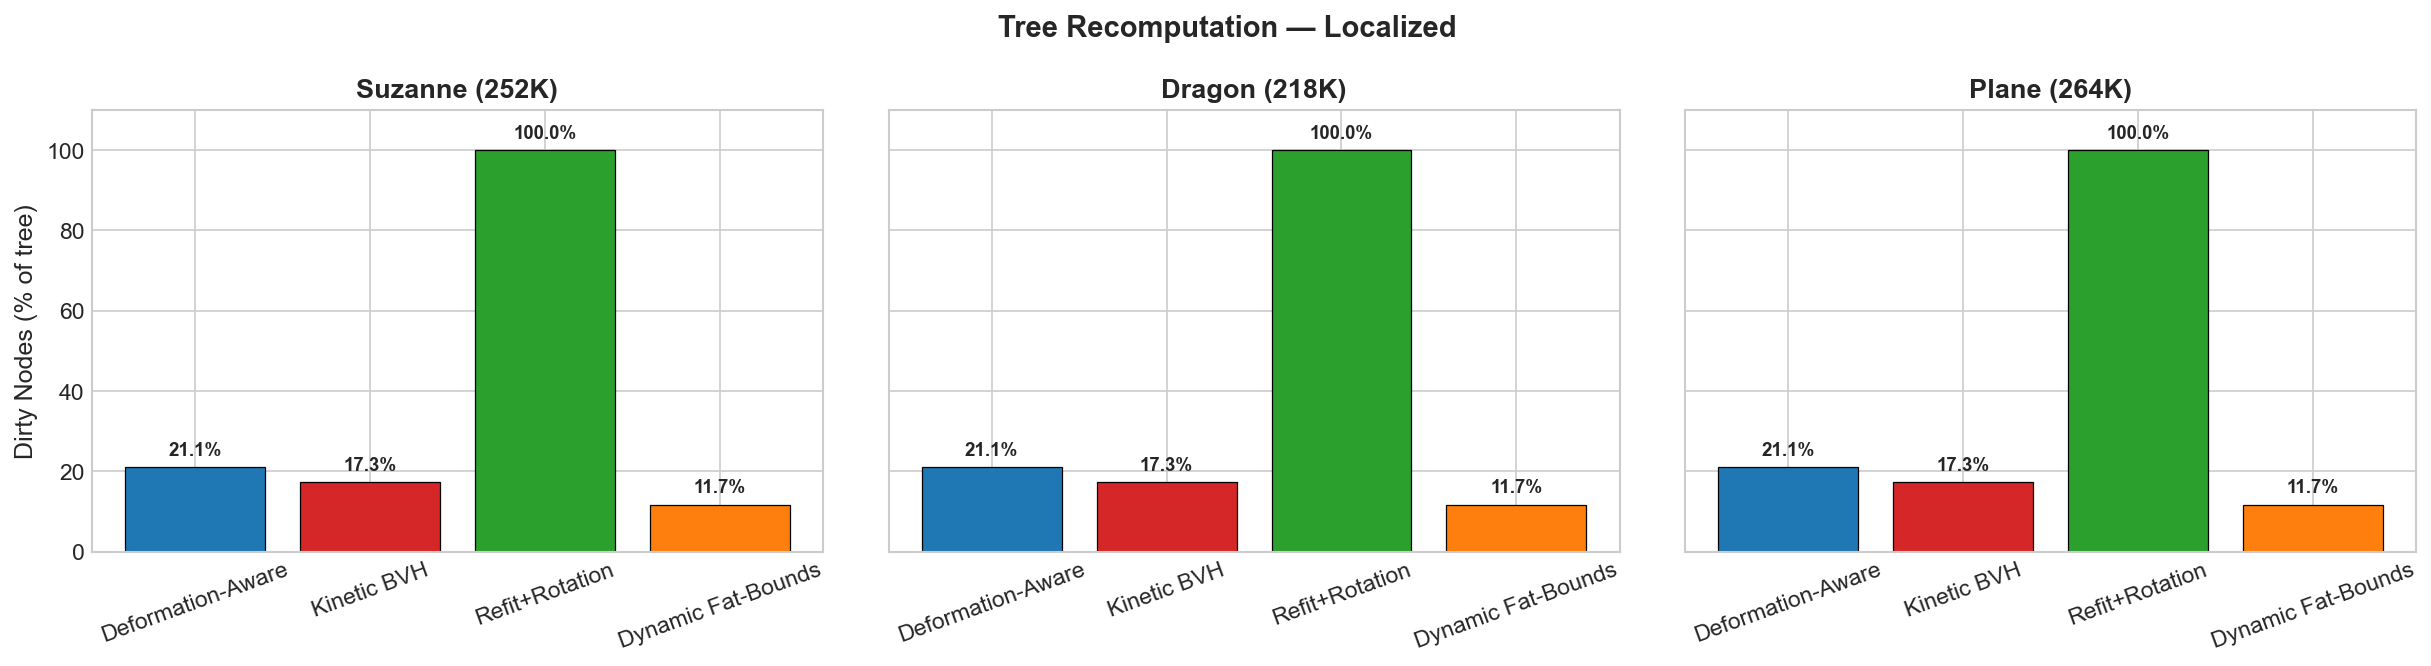

In [6]:
def plot_dirty_pct(deformation):
    fig, axes = plt.subplots(1, len(MESHES), figsize=(5.5 * len(MESHES), 4.5), sharey=True)
    if len(MESHES) == 1: axes = [axes]

    for ax, mesh in zip(axes, MESHES):
        _, max_tris = MESH_RESOLUTIONS[mesh][-1]
        pcts = []
        for method in METHODS:
            df, meta = load_method_data(method, deformation, max_tris)
            if df is not None and 'treeNodes' in meta:
                total_nodes = int(meta['treeNodes'])
                pcts.append(df['dirtyNodes'].mean() / total_nodes * 100 if total_nodes > 0 else 0)
            else:
                pcts.append(0)

        bars = ax.bar([METHOD_LABELS[m] for m in METHODS], pcts,
                     color=[METHOD_COLORS[m] for m in METHODS],
                     edgecolor='black', linewidth=0.6)
        ax.set_title(f'{mesh} ({MESH_RESOLUTIONS[mesh][-1][0]})', fontweight='bold')
        ax.set_ylim(0, 110)
        ax.tick_params(axis='x', rotation=20)

        for bar, val in zip(bars, pcts):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    axes[0].set_ylabel('Dirty Nodes (% of tree)')
    fig.suptitle(f'Tree Recomputation — {deformation}', fontweight='bold', fontsize=14)
    plt.tight_layout()
    savefig(f'fig_dirty_{deformation.lower()}')
    plt.show()

for d in DEFORMATIONS:
    plot_dirty_pct(d)

---
## Figure 5 — Per-Frame Timeline (Highest Resolution)
Update time over the movement cycle. Shows collision spike response.

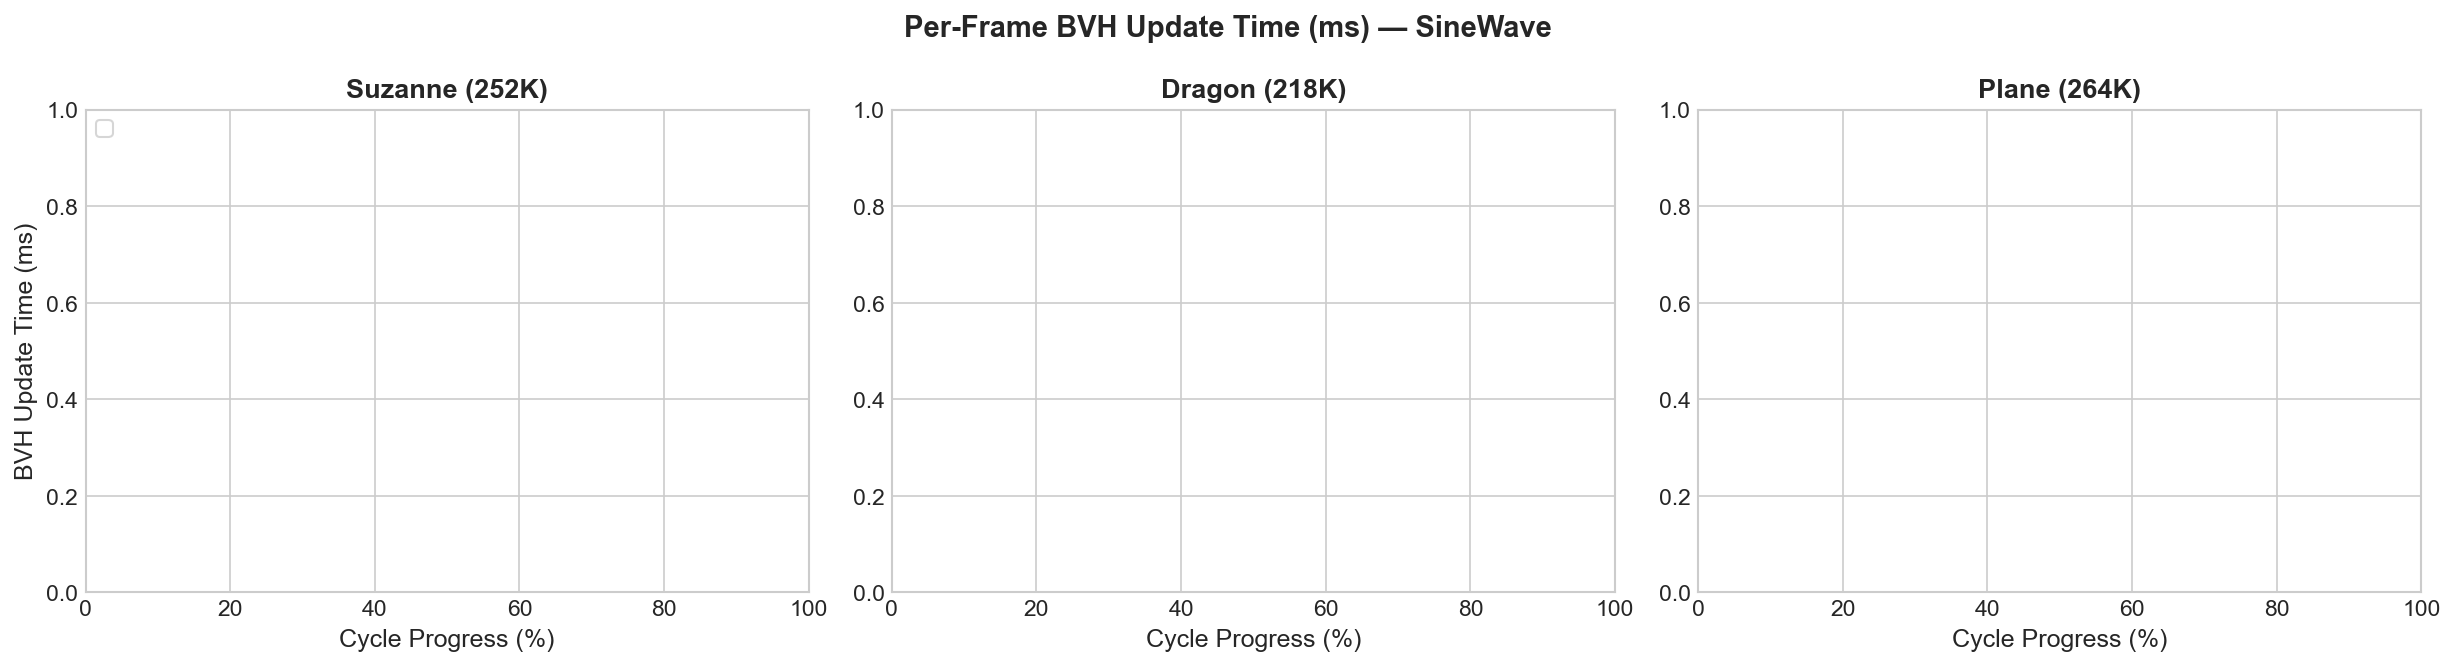

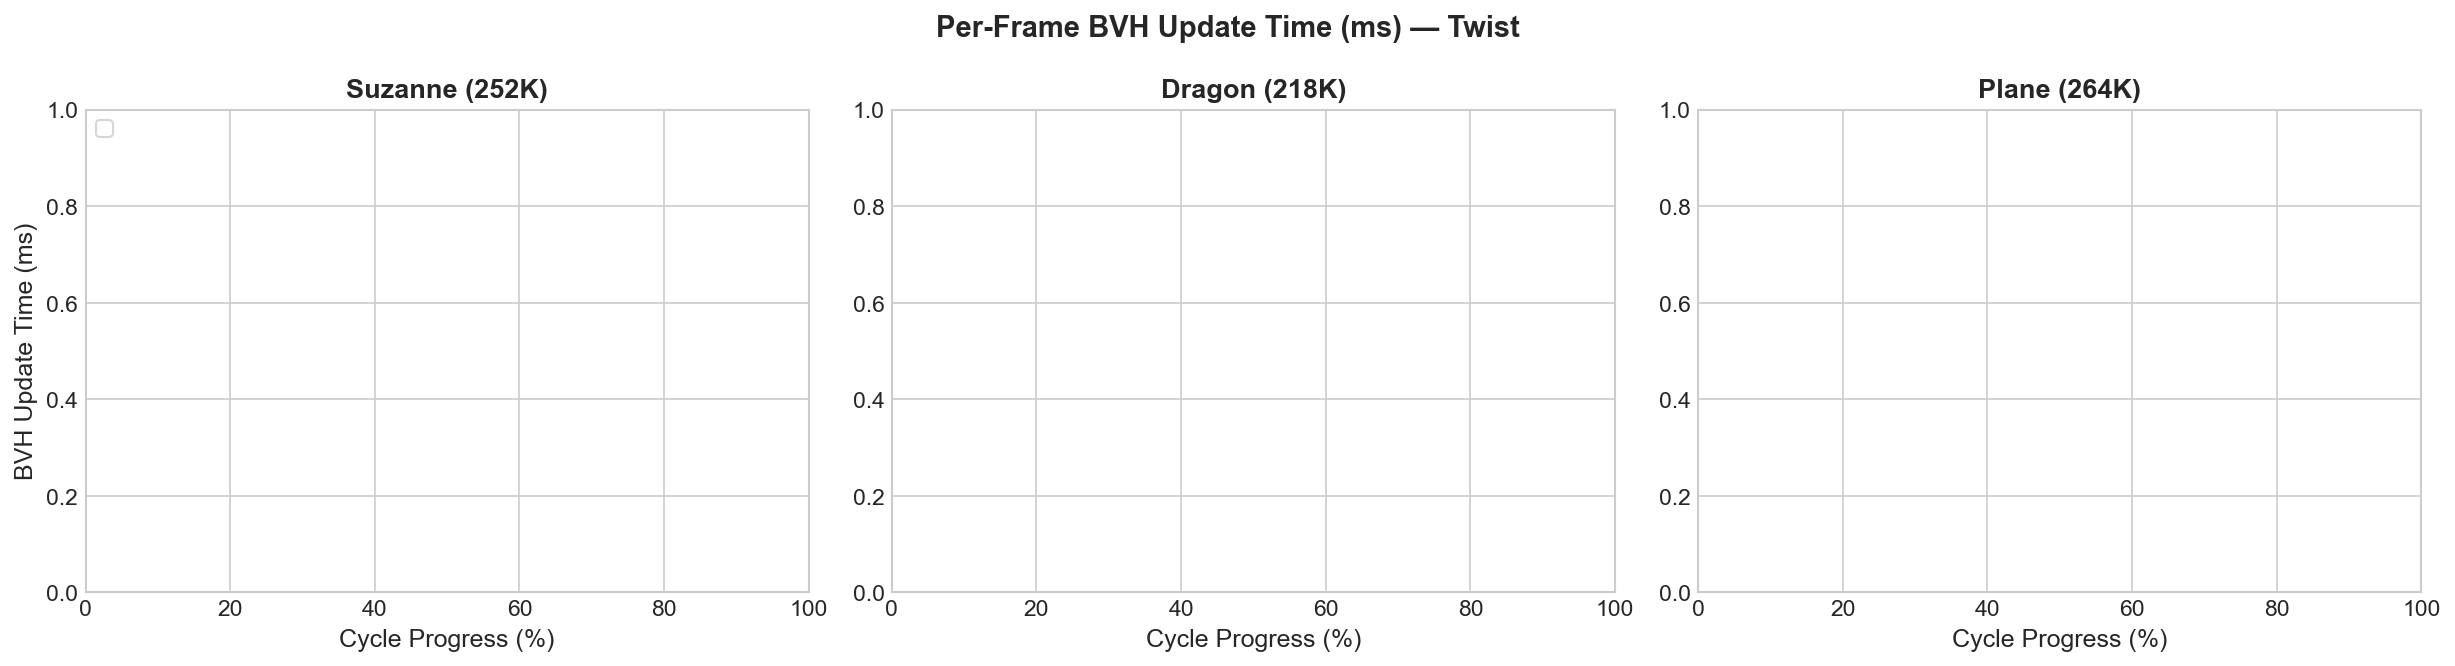

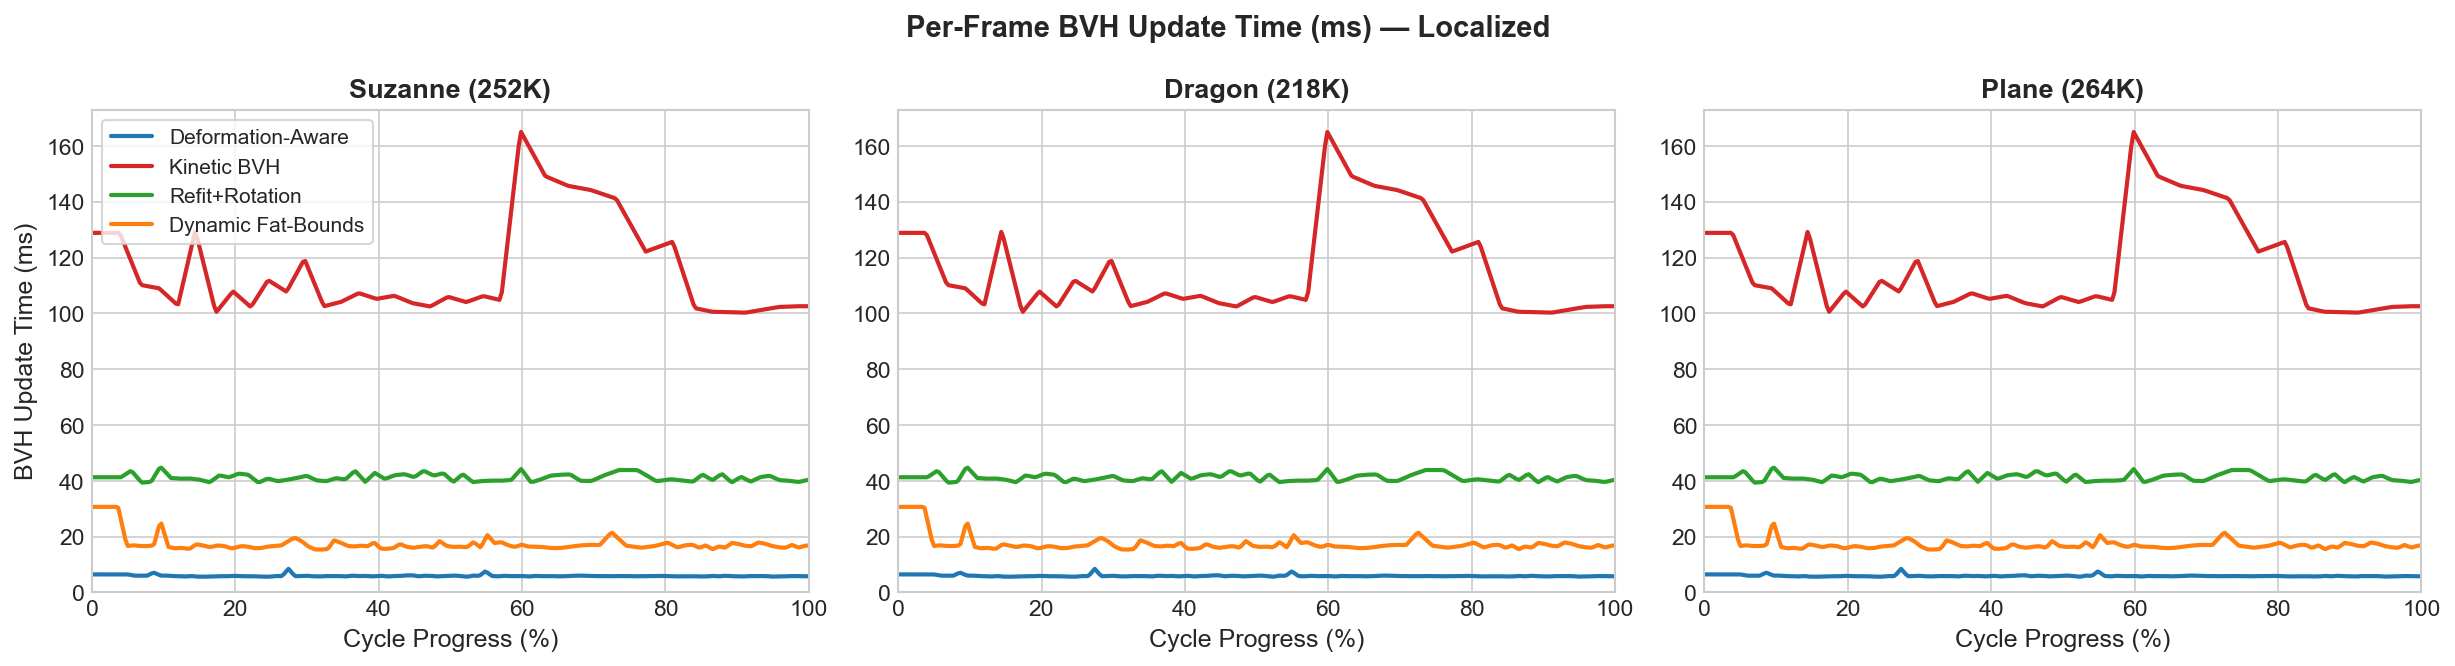

In [7]:
def plot_timeline(deformation, metric='updateMs', ylabel='BVH Update Time (ms)'):
    fig, axes = plt.subplots(1, len(MESHES), figsize=(5.5 * len(MESHES), 4.5), sharey=False)
    if len(MESHES) == 1: axes = [axes]

    for ax, mesh in zip(axes, MESHES):
        _, max_tris = MESH_RESOLUTIONS[mesh][-1]

        for method in METHODS:
            df, _ = load_method_data(method, deformation, max_tris)
            if df is None: continue
            x, y, std = get_averaged_line(df, metric)
            ax.plot(x, y, color=METHOD_COLORS[method], linewidth=2,
                   label=METHOD_LABELS[method])
            if std.max() > 0.1:
                ax.fill_between(x, y - std, y + std,
                               color=METHOD_COLORS[method], alpha=0.1)

        ax.set_title(f'{mesh} ({MESH_RESOLUTIONS[mesh][-1][0]})', fontweight='bold')
        ax.set_xlabel('Cycle Progress (%)')
        ax.set_xlim(0, 100)
        ax.set_ylim(bottom=0)

    axes[0].set_ylabel(ylabel)
    axes[0].legend(frameon=True, loc='upper left')
    fig.suptitle(f'Per-Frame {ylabel} — {deformation}', fontweight='bold', fontsize=14)
    plt.tight_layout()
    savefig(f'fig_timeline_{metric}_{deformation.lower()}')
    plt.show()

for d in DEFORMATIONS:
    plot_timeline(d, 'updateMs', 'BVH Update Time (ms)')

---
## Figure 6 — Speedup vs Refit+Rotation Baseline
Normalized comparison: how many times faster each method is.

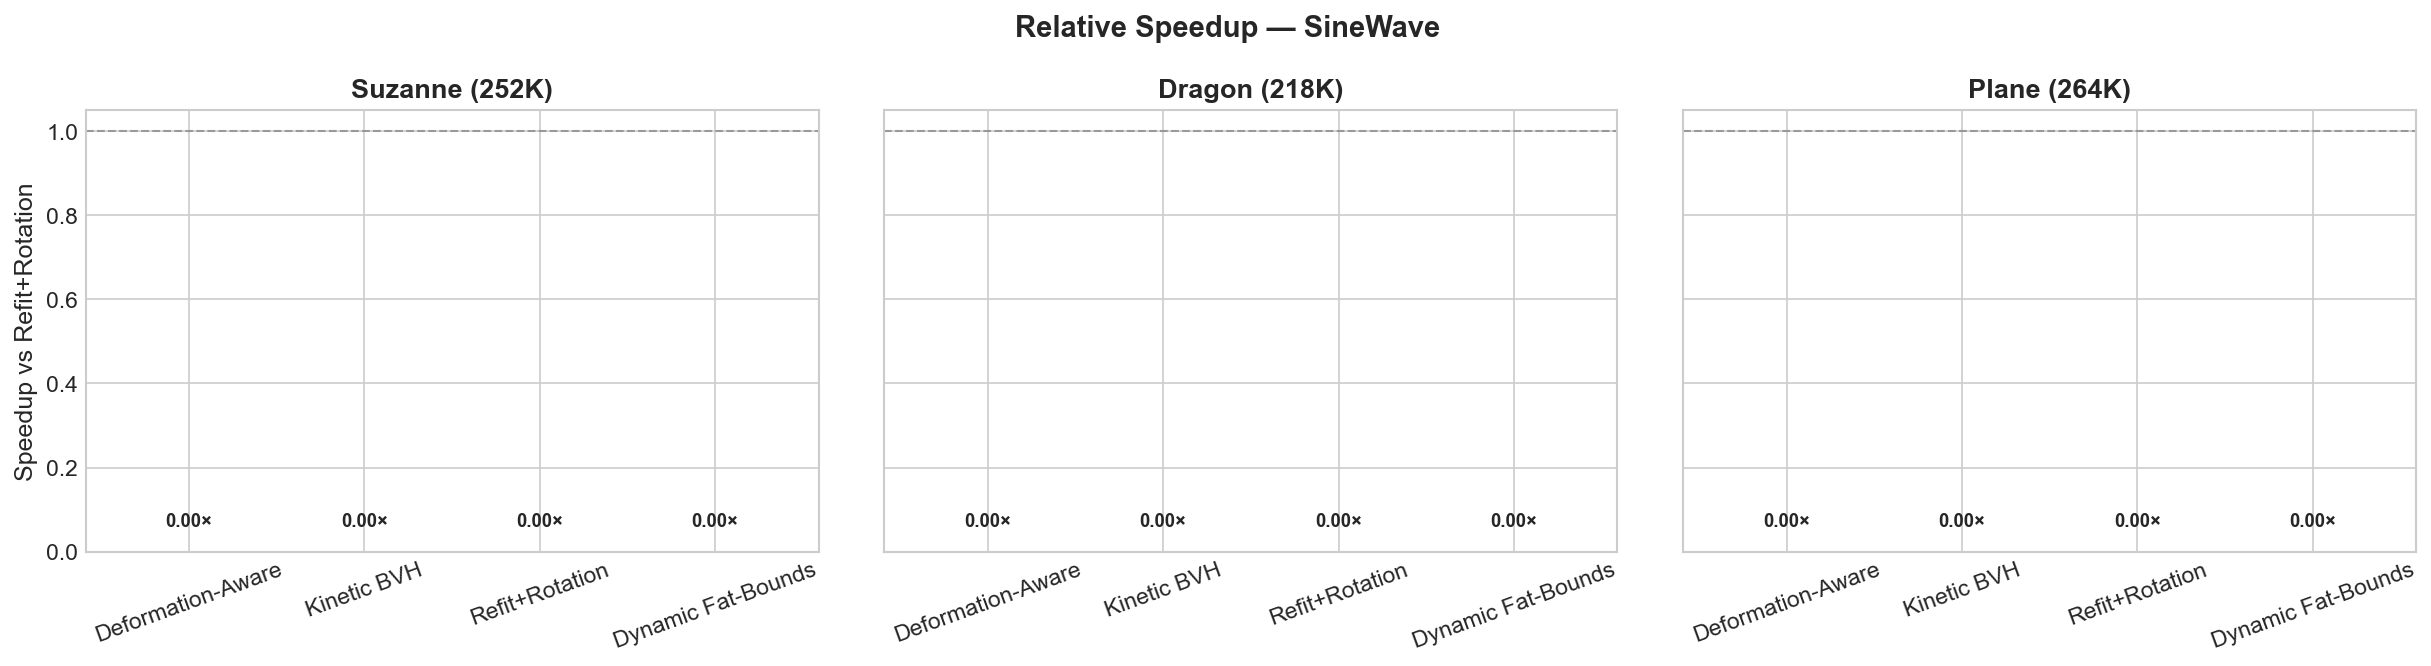

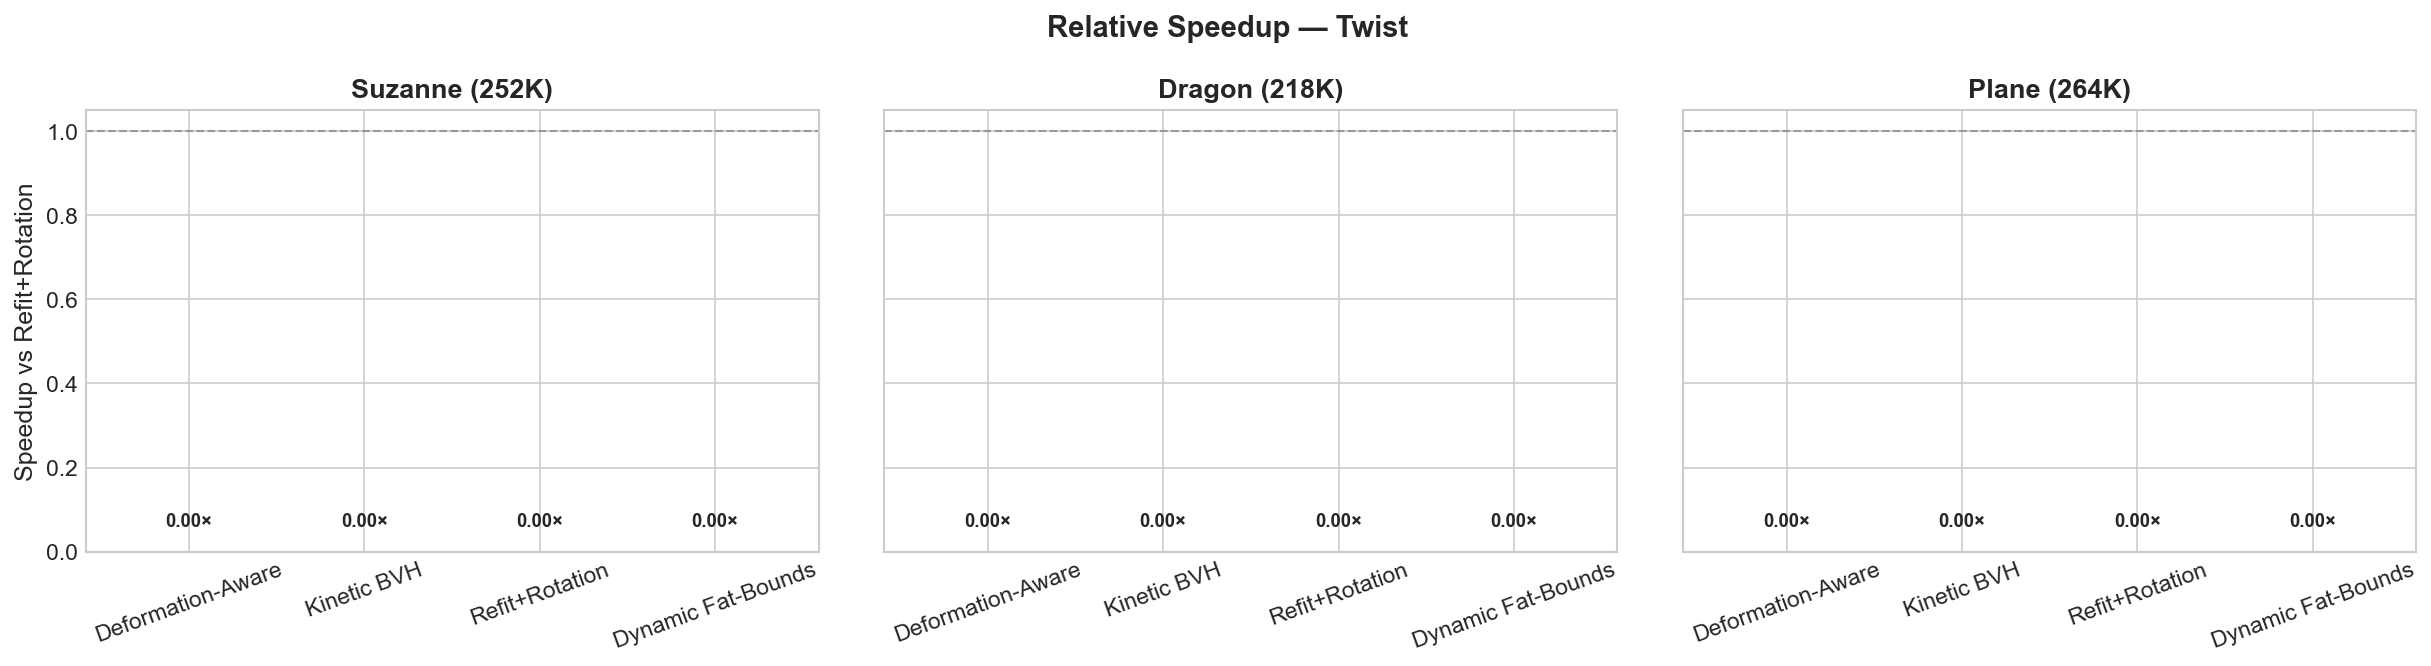

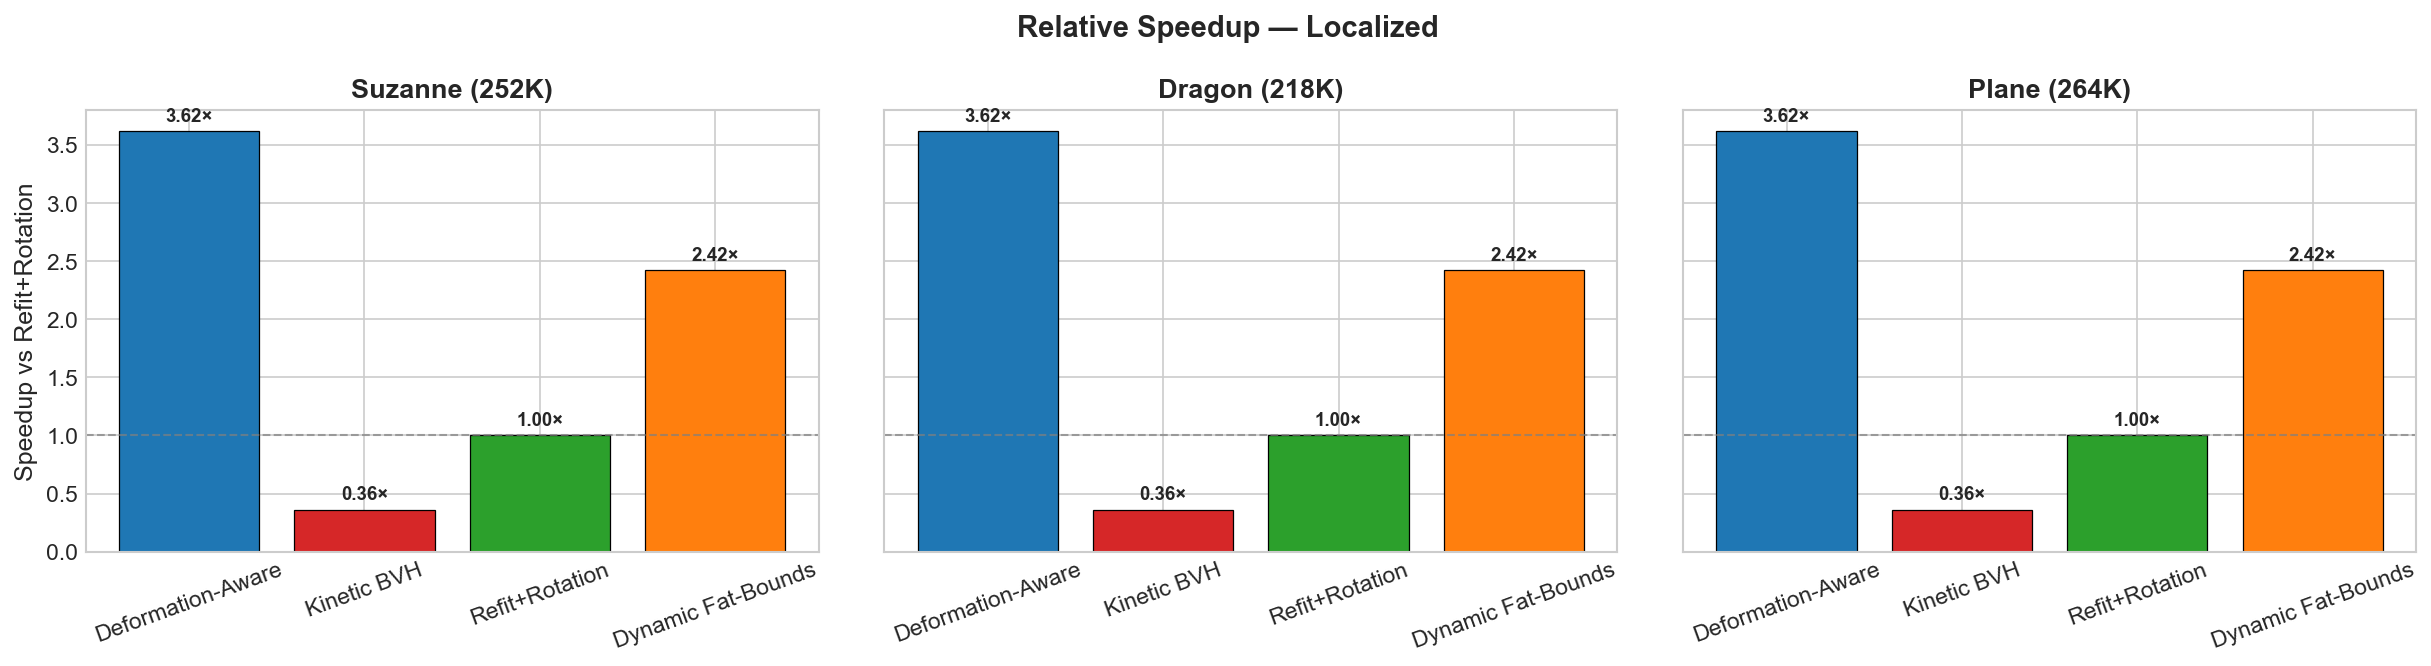

In [8]:
def plot_speedup(deformation):
    fig, axes = plt.subplots(1, len(MESHES), figsize=(5.5 * len(MESHES), 4.5), sharey=True)
    if len(MESHES) == 1: axes = [axes]

    for ax, mesh in zip(axes, MESHES):
        _, max_tris = MESH_RESOLUTIONS[mesh][-1]
        baseline_overhead, _ = compute_overhead('RefitRotate', deformation, max_tris)

        speedups = []
        for method in METHODS:
            overhead, _ = compute_overhead(method, deformation, max_tris)
            speedups.append(baseline_overhead / overhead if overhead > 0 else 0)

        bars = ax.bar([METHOD_LABELS[m] for m in METHODS], speedups,
                     color=[METHOD_COLORS[m] for m in METHODS],
                     edgecolor='black', linewidth=0.6)
        ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
        ax.set_title(f'{mesh} ({MESH_RESOLUTIONS[mesh][-1][0]})', fontweight='bold')
        ax.tick_params(axis='x', rotation=20)
        ax.set_ylim(bottom=0)

        for bar, val in zip(bars, speedups):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    f'{val:.2f}×', ha='center', va='bottom', fontsize=9, fontweight='bold')

    axes[0].set_ylabel('Speedup vs Refit+Rotation')
    fig.suptitle(f'Relative Speedup — {deformation}', fontweight='bold', fontsize=14)
    plt.tight_layout()
    savefig(f'fig_speedup_{deformation.lower()}')
    plt.show()

for d in DEFORMATIONS:
    plot_speedup(d)

---
## Figure 7 — Global vs Localized Side-by-Side
Shows that Aware's advantage grows with deformation locality.

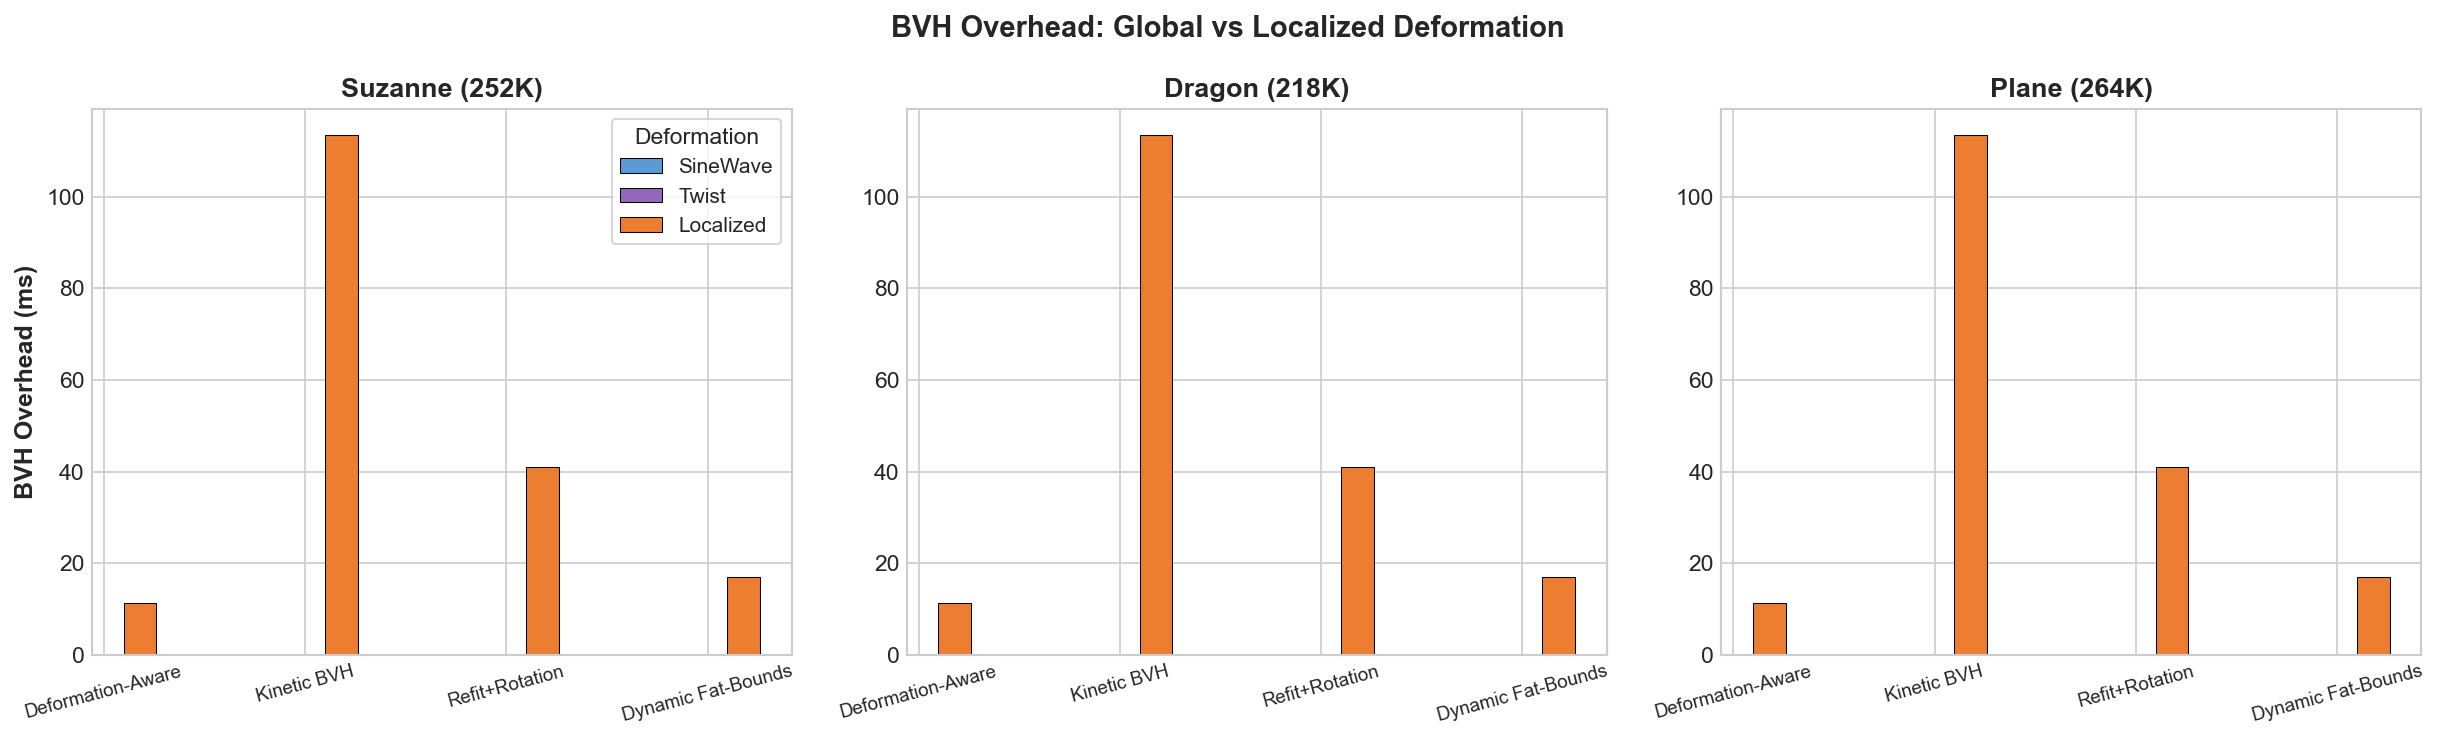

In [9]:
fig, axes = plt.subplots(1, len(MESHES), figsize=(5.5 * len(MESHES), 5), sharey=False)
if len(MESHES) == 1: axes = [axes]

bar_width = 0.18
compare_deforms = ['SineWave', 'Twist', 'Localized']
deform_colors = ['#5b9bd5', '#9467bd', '#ed7d31']

for ax, mesh in zip(axes, MESHES):
    _, max_tris = MESH_RESOLUTIONS[mesh][-1]
    x = np.arange(len(METHODS))

    for di, (deform, color) in enumerate(zip(compare_deforms, deform_colors)):
        means = []
        for method in METHODS:
            m, _ = compute_overhead(method, deform, max_tris)
            means.append(m)
        offset = (di - len(compare_deforms)/2 + 0.5) * bar_width
        ax.bar(x + offset, means, bar_width * 0.9, color=color, edgecolor='black',
              linewidth=0.5, label=deform if mesh == MESHES[0] else None)

    ax.set_title(f'{mesh} ({MESH_RESOLUTIONS[mesh][-1][0]})', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([METHOD_LABELS[m] for m in METHODS], fontsize=9, rotation=15)
    ax.set_ylim(bottom=0)

axes[0].set_ylabel('BVH Overhead (ms)', fontweight='bold')
axes[0].legend(title='Deformation', frameon=True)
fig.suptitle('BVH Overhead: Global vs Localized Deformation', fontweight='bold', fontsize=14)
plt.tight_layout()
savefig('fig_global_vs_localized')
plt.show()

---
## Figure 8 — Query Culling Quality
Nodes visited during collision query. Similar values = same tree quality.

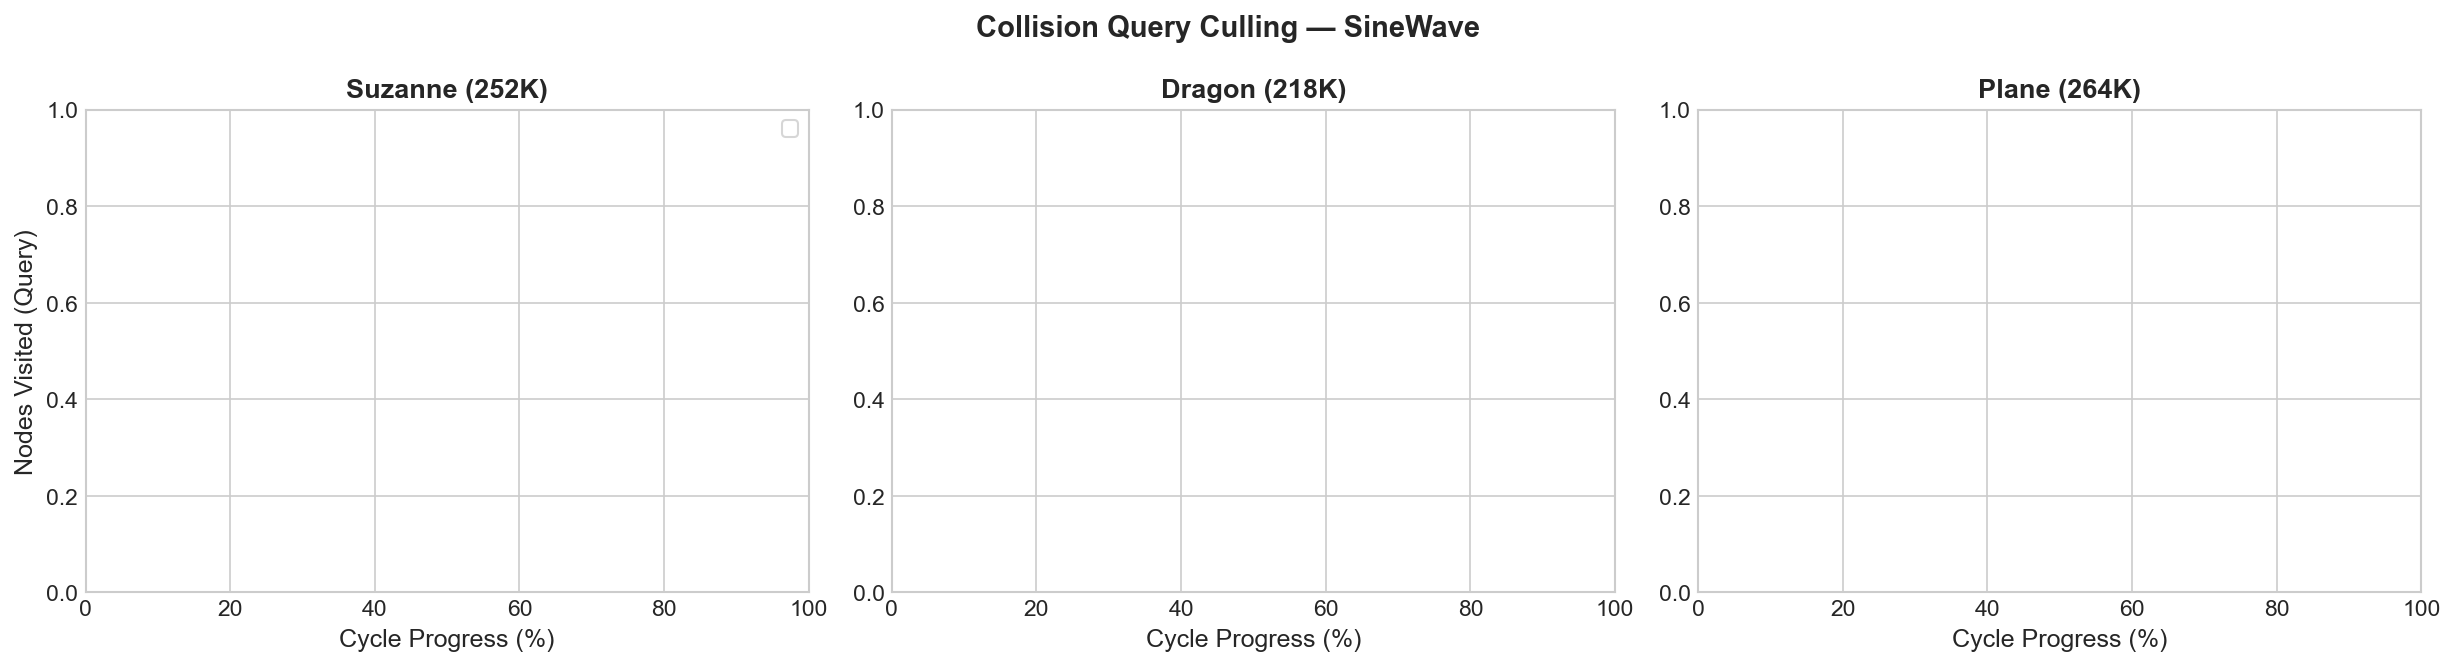

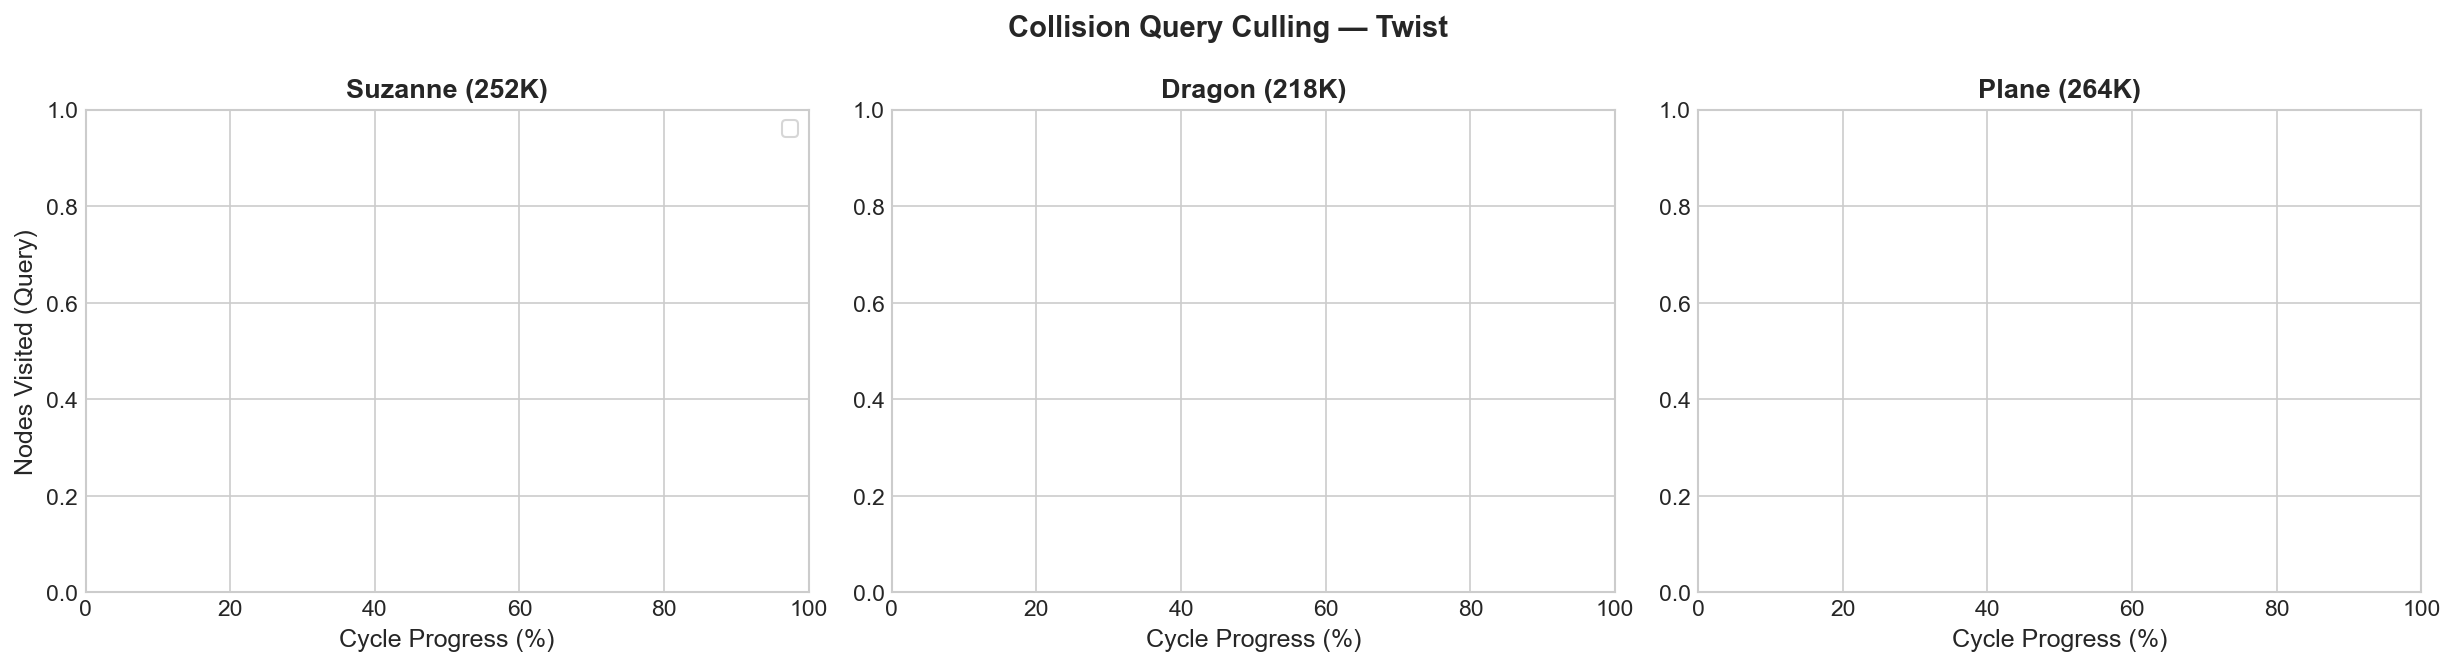

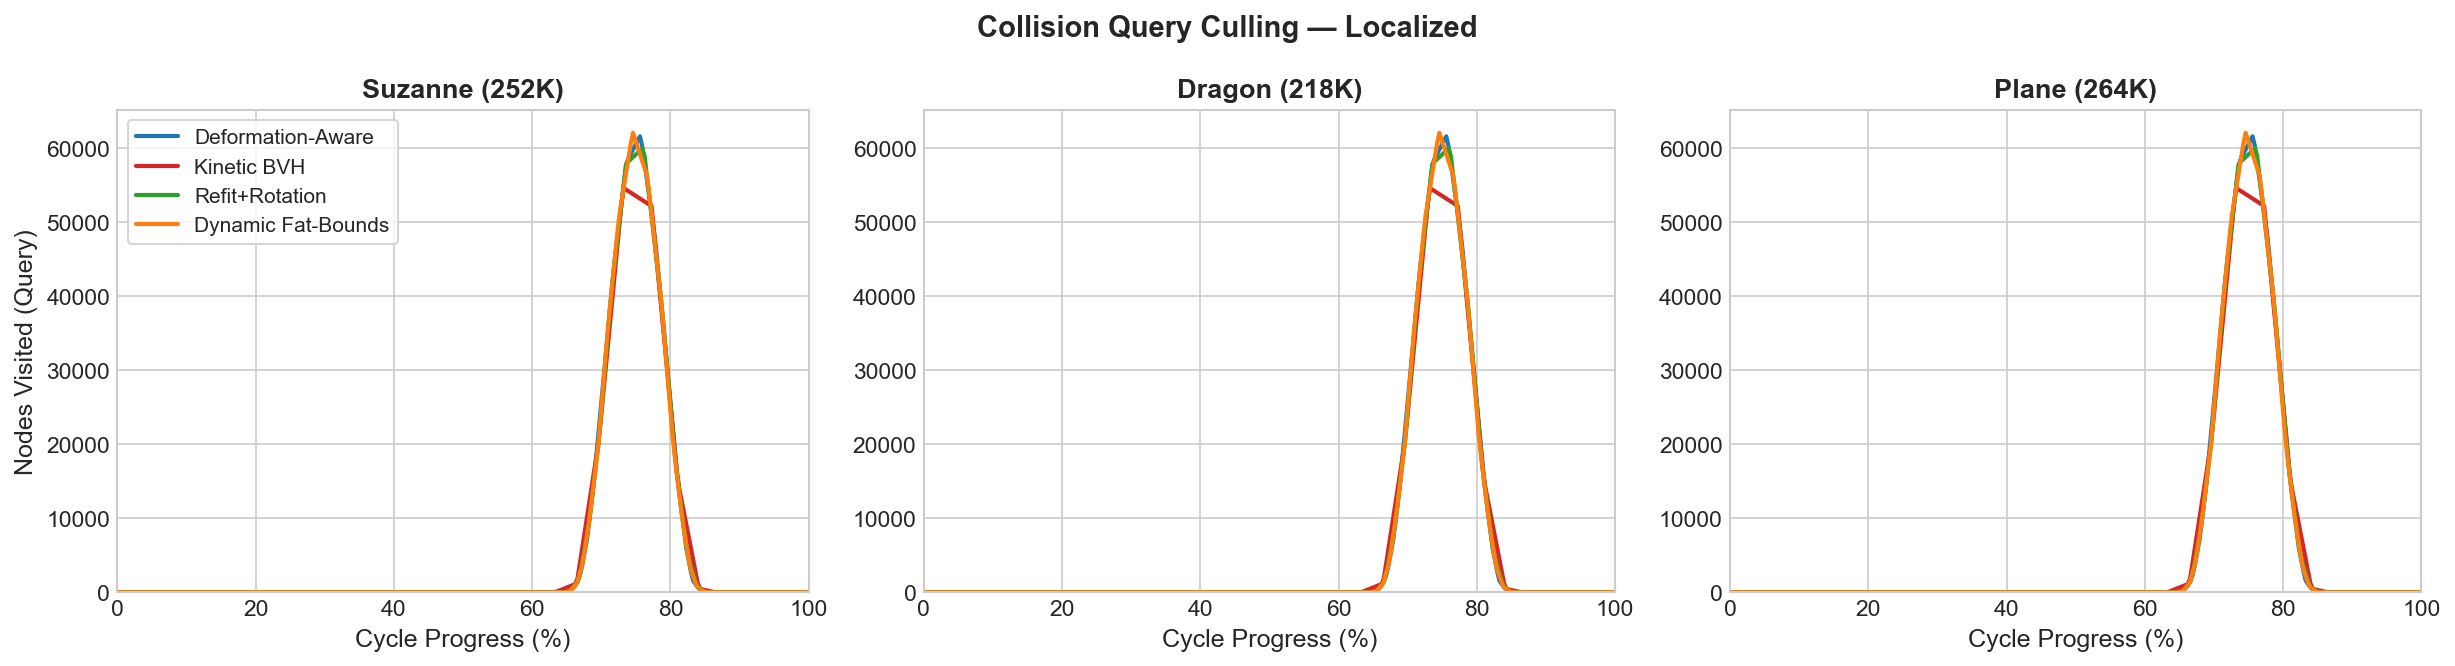

In [10]:
def plot_query(deformation):
    fig, axes = plt.subplots(1, len(MESHES), figsize=(5.5 * len(MESHES), 4.5), sharey=False)
    if len(MESHES) == 1: axes = [axes]

    for ax, mesh in zip(axes, MESHES):
        _, max_tris = MESH_RESOLUTIONS[mesh][-1]
        for method in METHODS:
            df, _ = load_method_data(method, deformation, max_tris)
            if df is None: continue
            x, y, _ = get_averaged_line(df, 'nodesVisitedQuery')
            ax.plot(x, y, color=METHOD_COLORS[method], linewidth=2,
                   label=METHOD_LABELS[method])

        ax.set_title(f'{mesh} ({MESH_RESOLUTIONS[mesh][-1][0]})', fontweight='bold')
        ax.set_xlabel('Cycle Progress (%)')
        ax.set_xlim(0, 100)
        ax.set_ylim(bottom=0)

    axes[0].set_ylabel('Nodes Visited (Query)')
    axes[0].legend(frameon=True)
    fig.suptitle(f'Collision Query Culling — {deformation}', fontweight='bold', fontsize=14)
    plt.tight_layout()
    savefig(f'fig_query_{deformation.lower()}')
    plt.show()

for d in DEFORMATIONS:
    plot_query(d)

---
## Figure 9 — Cross-Mesh Comparison at ~60K Triangles
How does mesh topology affect performance at similar resolution?

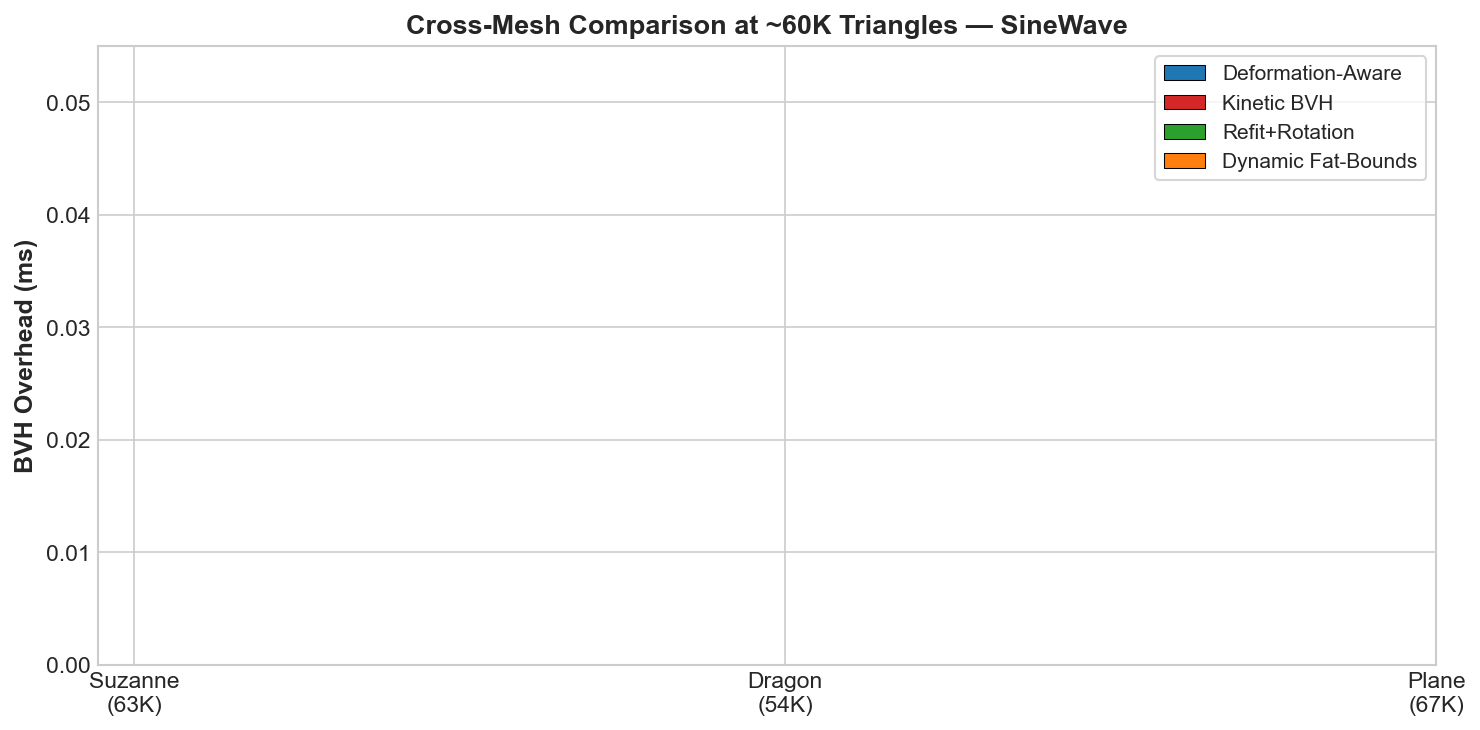

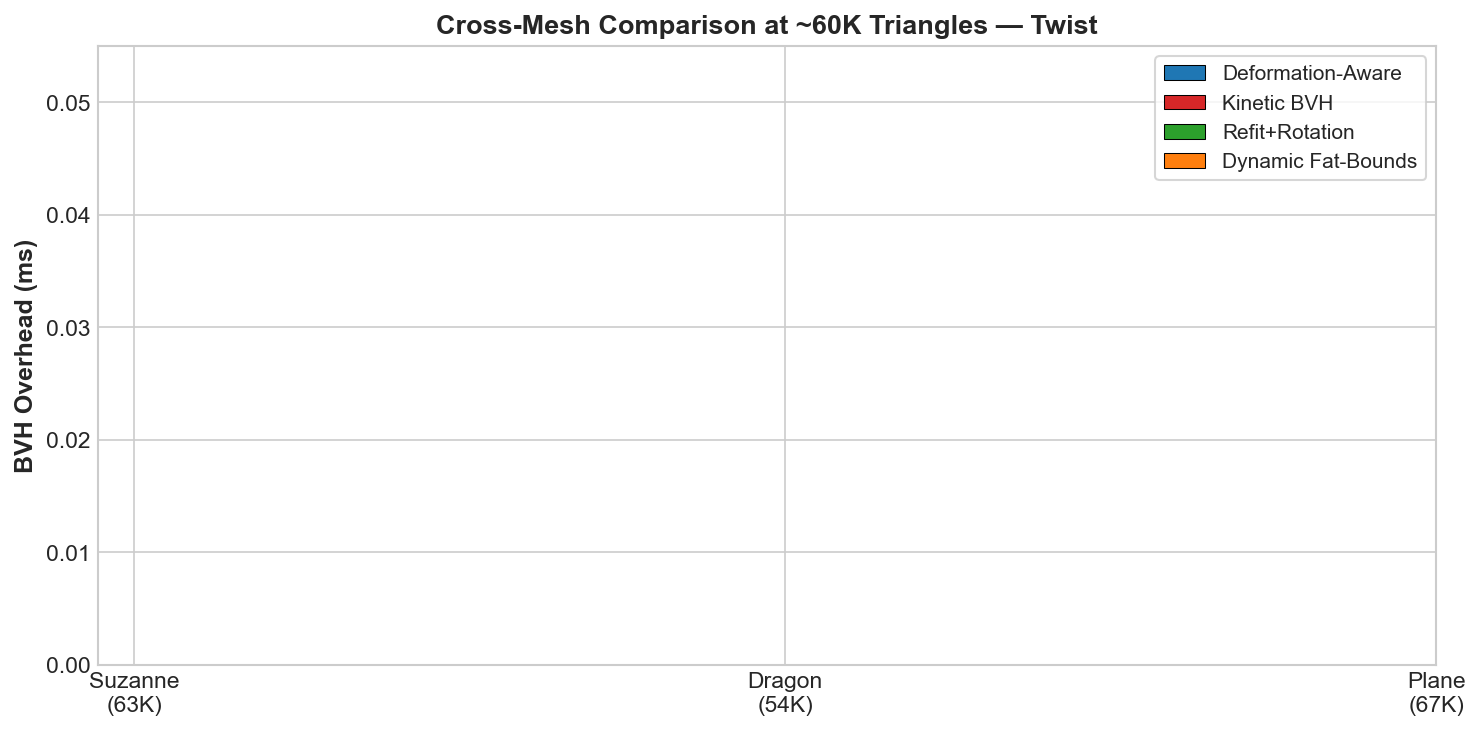

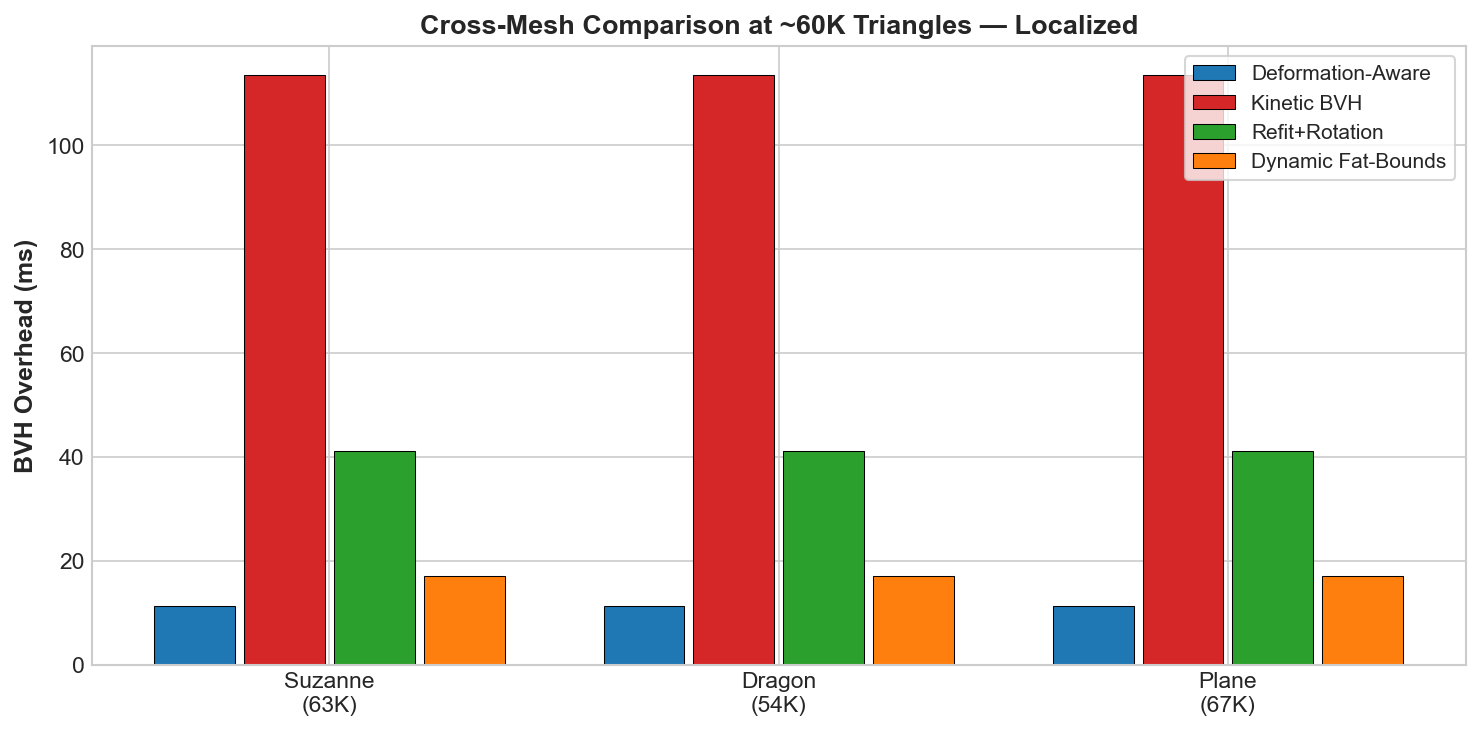

In [11]:
# Pick the ~60K resolution from each mesh
mid_res = {
    'Suzanne': MESH_RESOLUTIONS['Suzanne'][2],  # 63K
    'Dragon':  MESH_RESOLUTIONS['Dragon'][2],    # 54K
    'Plane':   MESH_RESOLUTIONS['Plane'][2],     # 67K
}

for deform in DEFORMATIONS:
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(MESHES))
    bar_width = 0.2

    for mi, method in enumerate(METHODS):
        means = []
        for mesh in MESHES:
            label, tri_count = mid_res[mesh]
            m, _ = compute_overhead(method, deform, tri_count)
            means.append(m)
        offset = (mi - len(METHODS)/2 + 0.5) * bar_width
        ax.bar(x + offset, means, bar_width * 0.9,
              color=METHOD_COLORS[method], edgecolor='black', linewidth=0.5,
              label=METHOD_LABELS[method])

    ax.set_xticks(x)
    ax.set_xticklabels([f'{m}\n({mid_res[m][0]})' for m in MESHES])
    ax.set_ylabel('BVH Overhead (ms)', fontweight='bold')
    ax.set_title(f'Cross-Mesh Comparison at ~60K Triangles — {deform}', fontweight='bold')
    ax.legend(frameon=True)
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    savefig(f'fig_cross_mesh_{deform.lower()}')
    plt.show()

---
## Table — Summary Statistics (LaTeX)
Generates a publication-ready table for each deformation type.

In [12]:
for deform in DEFORMATIONS:
    print(f'\n{"="*70}')
    print(f'  {deform} — Highest Resolution per Mesh')
    print(f'{"="*70}')
    rows = []
    for mesh in MESHES:
        _, max_tris = MESH_RESOLUTIONS[mesh][-1]
        for method in METHODS:
            df, meta = load_method_data(method, deform, max_tris)
            if df is None: continue
            tree_nodes = int(meta.get('treeNodes', 1))
            overhead, _ = compute_overhead(method, deform, max_tris)
            rows.append({
                'Mesh': mesh,
                'Method': METHOD_LABELS[method],
                'Overhead (ms)': f'{overhead:.2f}',
                'Update (ms)': f"{df['updateMs'].mean():.2f} ± {df['updateMs'].std():.2f}",
                'Verts Checked': f"{df['verticesChecked'].mean():,.0f}",
                'Dirty (%)': f"{df['dirtyNodes'].mean()/tree_nodes*100:.1f}",
                'Query Nodes': f"{df['nodesVisitedQuery'].mean():,.0f}",
            })

    summary = pd.DataFrame(rows)
    print(summary.to_string(index=False))
    print('\n--- LaTeX ---')
    print(summary.to_latex(index=False, escape=False))


  SineWave — Highest Resolution per Mesh
Empty DataFrame
Columns: []
Index: []

--- LaTeX ---
\begin{tabular}{}
\toprule
\midrule
\bottomrule
\end{tabular}


  Twist — Highest Resolution per Mesh
Empty DataFrame
Columns: []
Index: []

--- LaTeX ---
\begin{tabular}{}
\toprule
\midrule
\bottomrule
\end{tabular}


  Localized — Highest Resolution per Mesh
   Mesh             Method Overhead (ms)    Update (ms) Verts Checked Dirty (%) Query Nodes
Suzanne  Deformation-Aware         11.35    5.89 ± 0.36        23,871      21.1       3,114
Suzanne        Kinetic BVH        113.47 113.47 ± 16.80     3,474,277      17.3       4,007
Suzanne     Refit+Rotation         41.10   41.10 ± 1.41       653,448     100.0       3,703
Suzanne Dynamic Fat-Bounds         16.97   16.97 ± 1.96       653,448      11.7       3,273
 Dragon  Deformation-Aware         11.35    5.89 ± 0.36        23,871      21.1       3,114
 Dragon        Kinetic BVH        113.47 113.47 ± 16.80     3,474,277      17.3       4,007


---
## Figure 10 — Scaling Trend: Speedup vs Triangle Count
Shows Aware's advantage growing with mesh complexity.

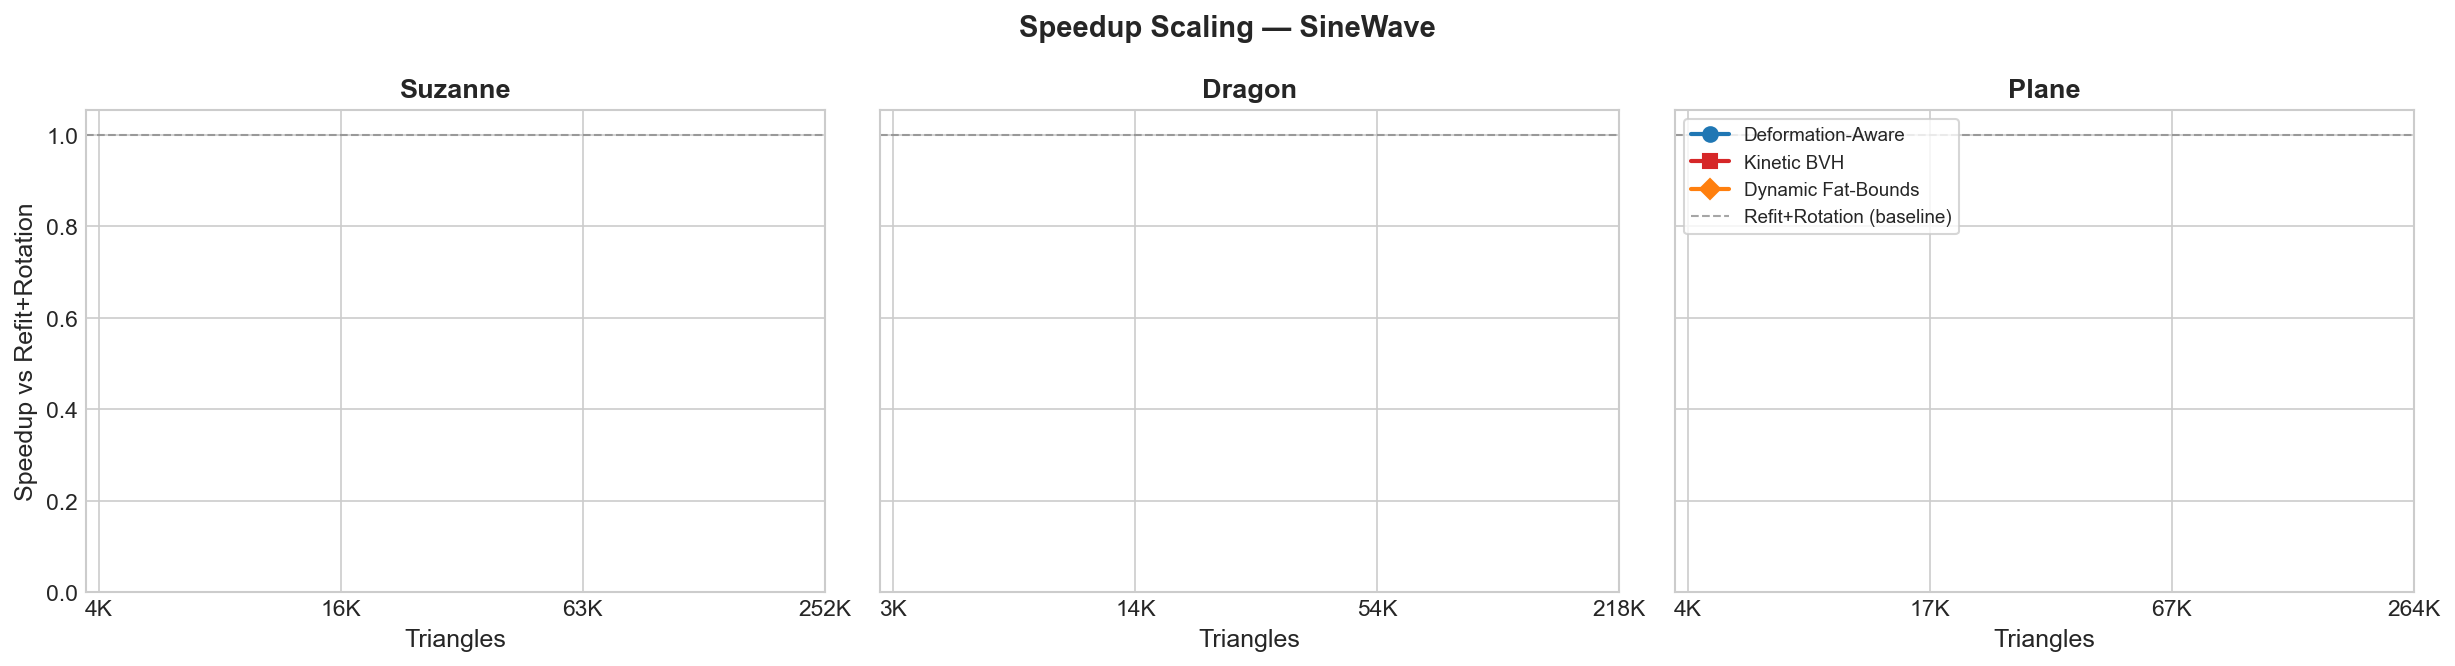

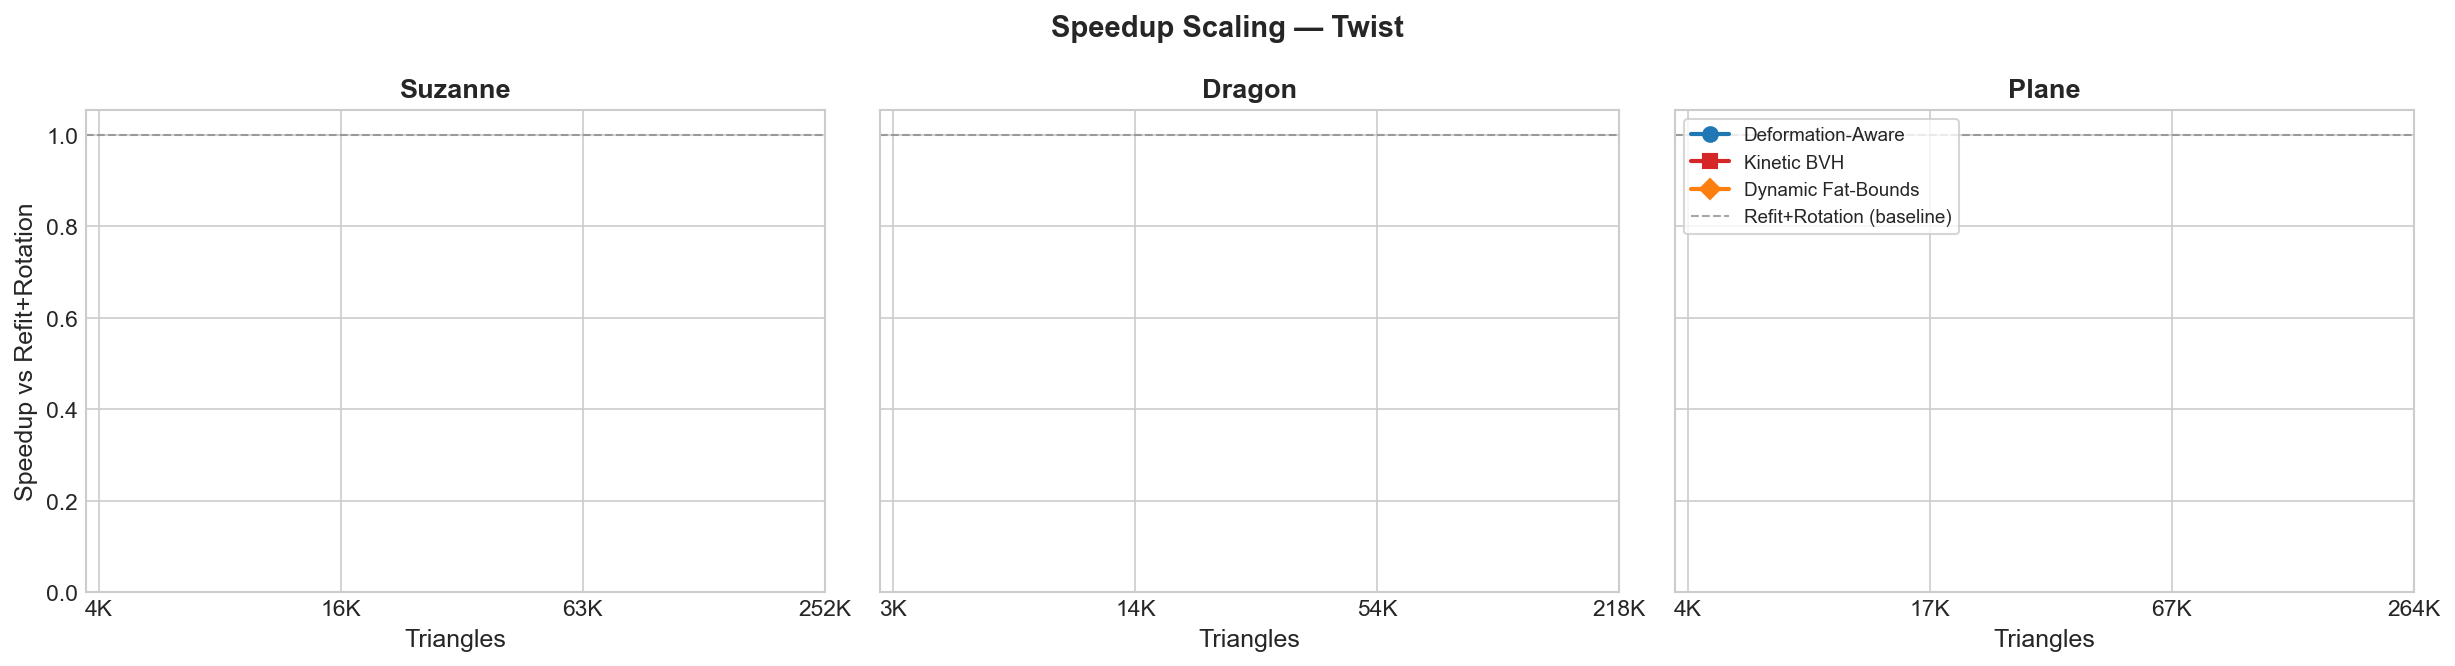

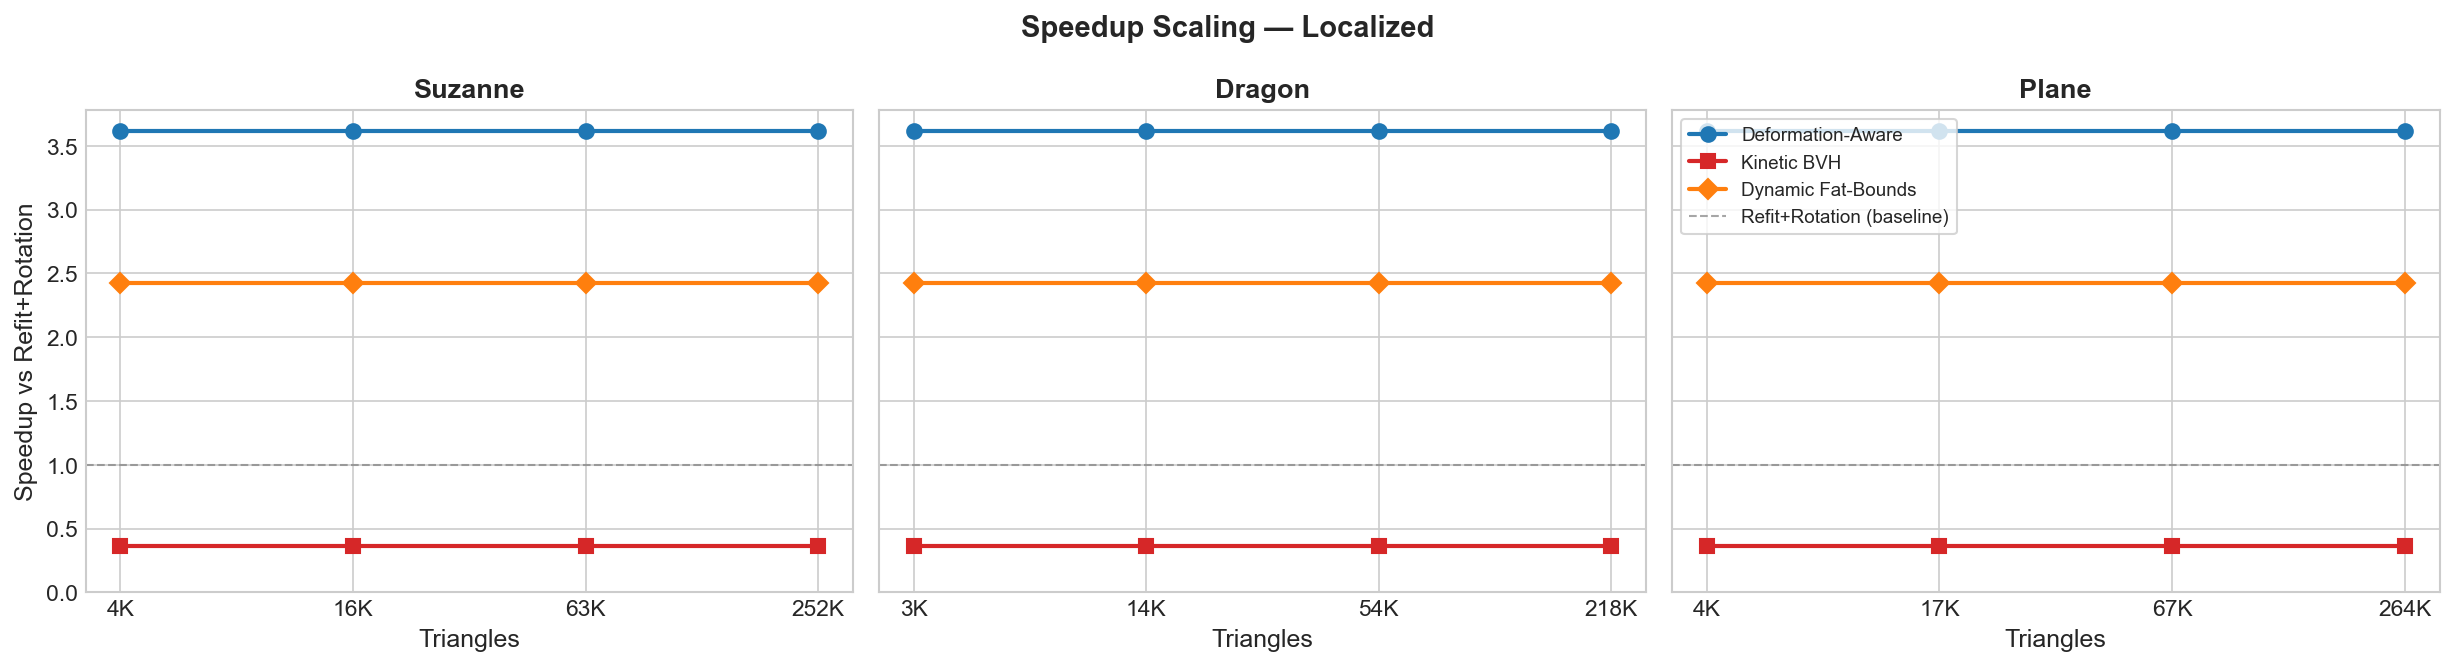

In [13]:
def plot_speedup_scaling(deformation):
    fig, axes = plt.subplots(1, len(MESHES), figsize=(5.5 * len(MESHES), 4.5), sharey=True)
    if len(MESHES) == 1: axes = [axes]

    for ax, mesh in zip(axes, MESHES):
        resolutions = MESH_RESOLUTIONS[mesh]
        labels_x = [r[0] for r in resolutions]

        for method in METHODS:
            if method == 'RefitRotate': continue  # baseline = 1.0 always
            speedups = []
            for _, tri_count in resolutions:
                base, _ = compute_overhead('RefitRotate', deformation, tri_count)
                curr, _ = compute_overhead(method, deformation, tri_count)
                speedups.append(base / curr if curr > 0 and base > 0 else np.nan)

            ax.plot(range(len(resolutions)), speedups,
                   marker=METHOD_MARKERS[method], color=METHOD_COLORS[method],
                   linewidth=2, markersize=7, label=METHOD_LABELS[method])

        ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.7,
                  label='Refit+Rotation (baseline)')
        ax.set_title(f'{mesh}', fontweight='bold')
        ax.set_xticks(range(len(labels_x)))
        ax.set_xticklabels(labels_x)
        ax.set_xlabel('Triangles')
        ax.set_ylim(bottom=0)

    axes[0].set_ylabel('Speedup vs Refit+Rotation')
    axes[-1].legend(frameon=True, loc='upper left', fontsize=9)
    fig.suptitle(f'Speedup Scaling — {deformation}', fontweight='bold', fontsize=14)
    plt.tight_layout()
    savefig(f'fig_speedup_scaling_{deformation.lower()}')
    plt.show()

for d in DEFORMATIONS:
    plot_speedup_scaling(d)

---
## Figure 11 — Time Breakdown (Stacked Bar per Method)
Shows deformation vs update vs query time at highest resolution.

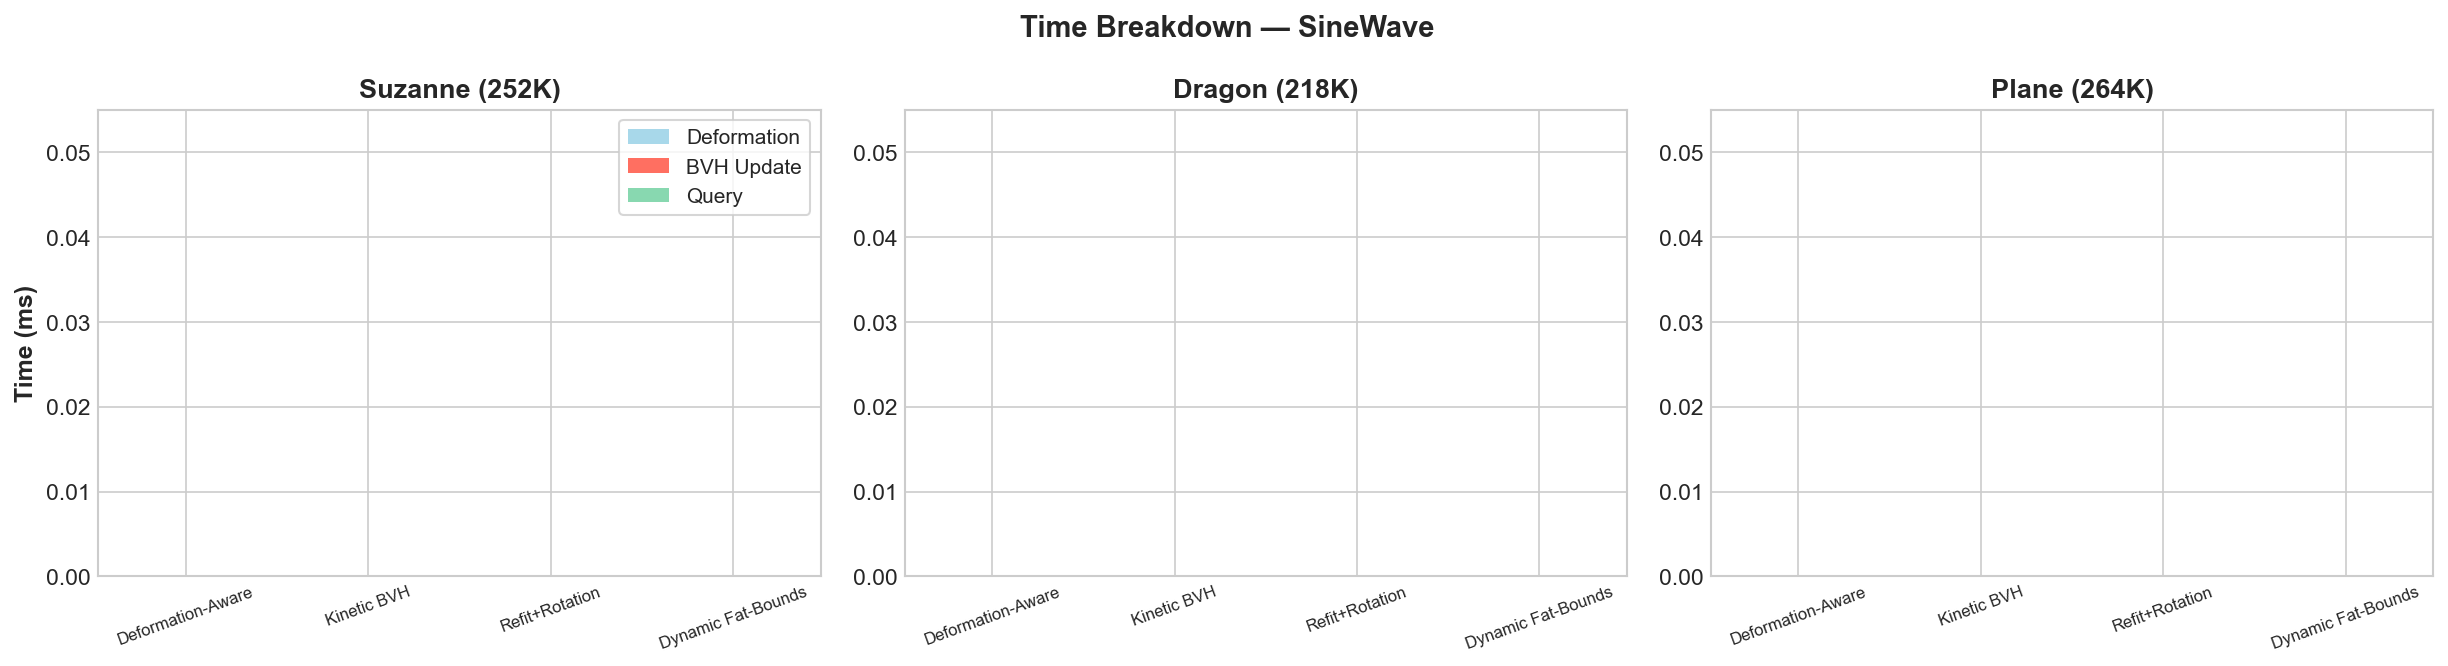

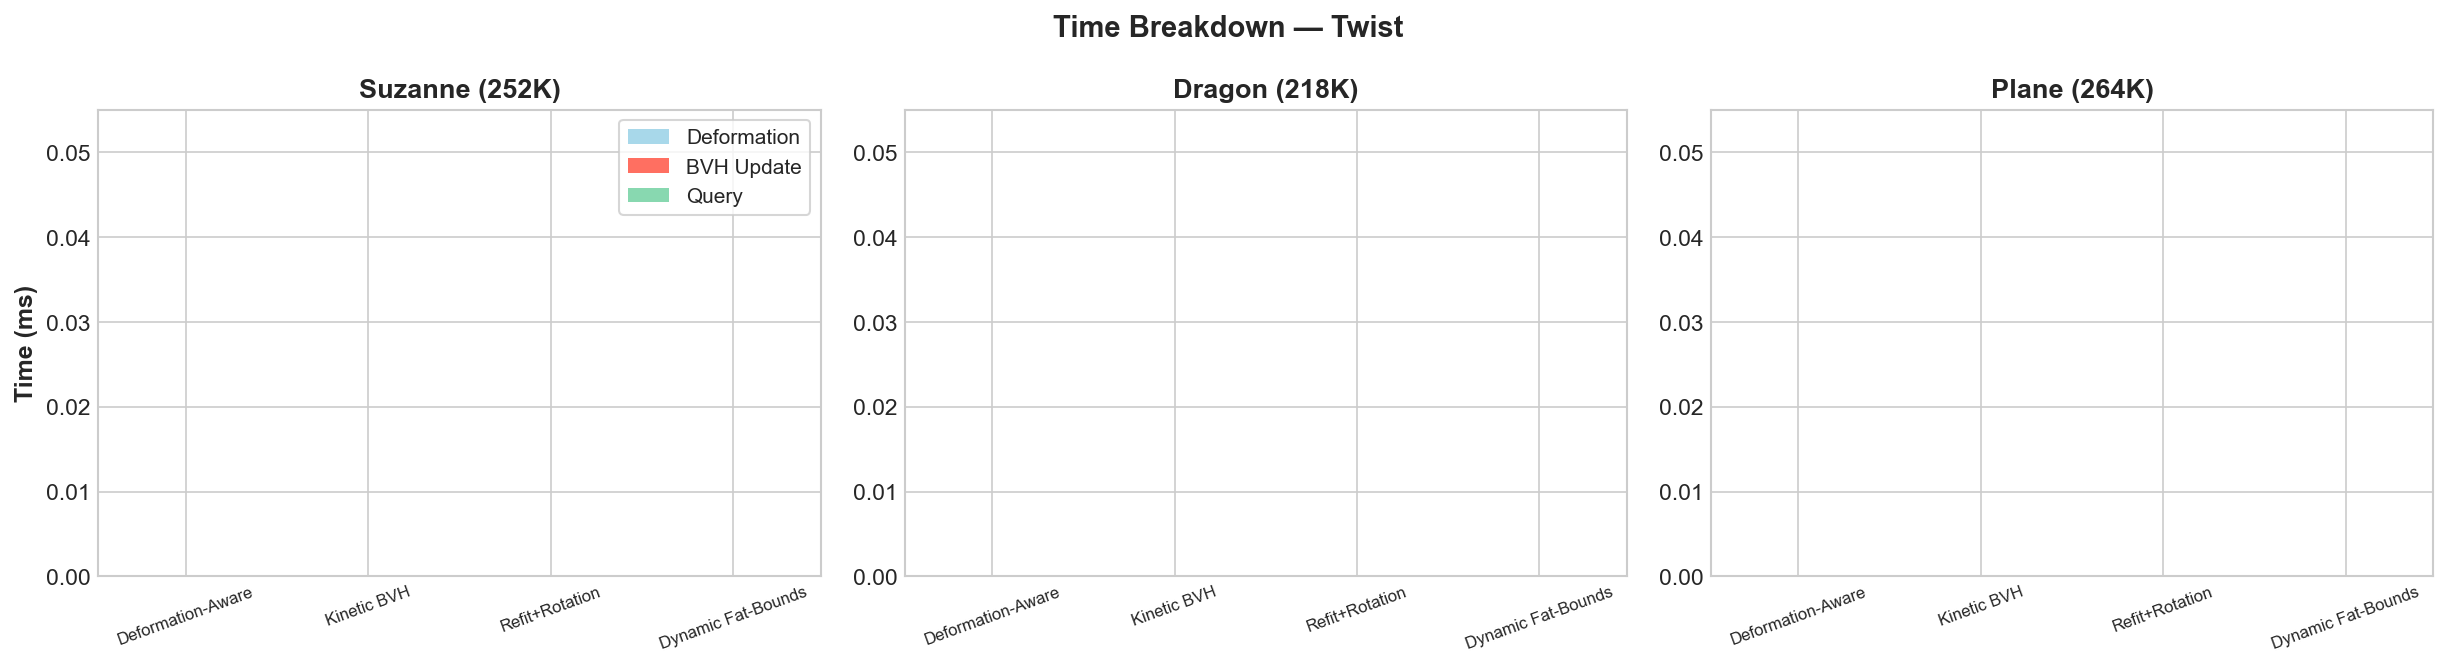

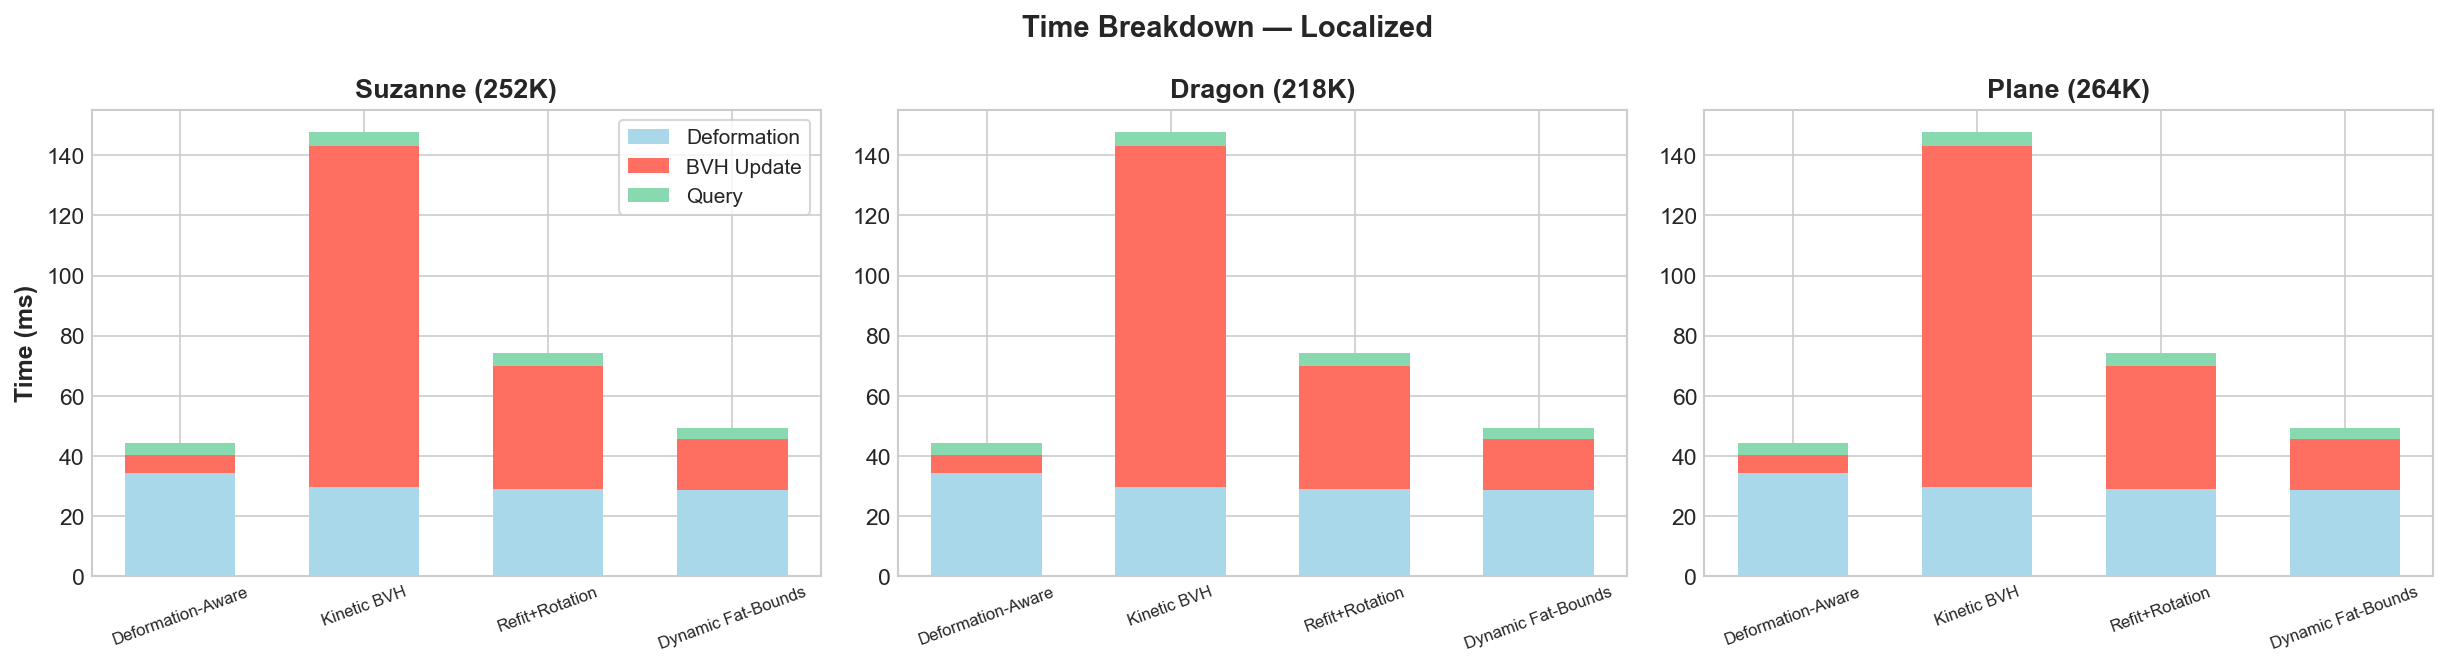

In [14]:
phase_colors = ['#a8d8ea', '#ff6f61', '#88d8b0']
phase_labels = ['Deformation', 'BVH Update', 'Query']

for deform in DEFORMATIONS:
    fig, axes = plt.subplots(1, len(MESHES), figsize=(5.5 * len(MESHES), 4.5), sharey=False)
    if len(MESHES) == 1: axes = [axes]

    for ax, mesh in zip(axes, MESHES):
        _, max_tris = MESH_RESOLUTIONS[mesh][-1]
        deform_vals, update_vals, query_vals = [], [], []

        for method in METHODS:
            df, _ = load_method_data(method, deform, max_tris)
            if df is not None:
                deform_vals.append(df['deformMs'].mean())
                update_vals.append(df['updateMs'].mean())
                query_vals.append(df['queryMs'].mean())
            else:
                deform_vals.append(0); update_vals.append(0); query_vals.append(0)

        x = np.arange(len(METHODS))
        ax.bar(x, deform_vals, 0.6, color=phase_colors[0], label=phase_labels[0] if mesh == MESHES[0] else None)
        ax.bar(x, update_vals, 0.6, bottom=deform_vals, color=phase_colors[1], label=phase_labels[1] if mesh == MESHES[0] else None)
        bottoms = [d + u for d, u in zip(deform_vals, update_vals)]
        ax.bar(x, query_vals, 0.6, bottom=bottoms, color=phase_colors[2], label=phase_labels[2] if mesh == MESHES[0] else None)

        ax.set_xticks(x)
        ax.set_xticklabels([METHOD_LABELS[m] for m in METHODS], fontsize=8, rotation=20)
        ax.set_title(f'{mesh} ({MESH_RESOLUTIONS[mesh][-1][0]})', fontweight='bold')
        ax.set_ylim(bottom=0)

    axes[0].set_ylabel('Time (ms)', fontweight='bold')
    axes[0].legend(frameon=True)
    fig.suptitle(f'Time Breakdown — {deform}', fontweight='bold', fontsize=14)
    plt.tight_layout()
    savefig(f'fig_breakdown_{deform.lower()}')
    plt.show()